# Project 3 - Sales Analysis - Machine Learning

## Objectives

- Transform the Date column to pandas datetime
- Read data from combined csv file created from ETL processes
- Create machine learning model to predict new hypothesis data
- Show plots to attempt to answer new hypothesis


## Inputs

CSV files used:

Sales_InvoiceData_Visualization.csv


## Outputs

Pipeline for use in streamlit 
Plots to show the data and attempt to answer the hypothesis


## Additional Comments

- Developed an experimental ETL library which is in this project (modETL_library.py)   
  Has lots of cool features so will be interesting to see how it works "in the field"

Used various AI tools to help with the visualisation process:
- ChatGPT
- GitHub Copilot

See Documents/What_AI_Used_For.md for more details.

Needed to install:

pip install nbformat

For plotly visualisations to work


- Isolated the visualisations into a seperate notebook to keep the file size as low as possible.


## Initalise Working Environment

In [73]:
%matplotlib inline

#iimport libraries
import os
import pandas as pd
import seaborn as sns
import plotly.express as px
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

#for ML experiments
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error, 
    r2_score
)
import statsmodels.formula.api as smf
import statsmodels.api as sm
import numpy as np

#for creating the pipeline file needed by streamlit/Heroku
import joblib

#below solution provided by chatGPT 
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root / "assets" / "python_files") not in sys.path:
    sys.path.insert(0, str(project_root / "assets" / "python_files"))
    
import modGlobal
import modETL_Library as modETL
#end solution provided by chatGPT


# Hypothesis Being Tested

- What are the predicted sales for store types by month for next year?
- What are the predicted sales for stores in areas of high unemployment by month for next year?

# Section 1 - Initalisation

## Intitialise All Variables To Be Used In Global Stack 

In [74]:
#model and image paths

#for test against existing values
CNST_STR_LINEAR_PIPELINE_HYPOTHESIS9_TEST_PATH = modGlobal.CNST_STR_MLPIPELINESPATH + "/linear_regression_hypothesis9_test_pipeline.pkl"
CNST_STR_LINEAR_PLOT_HYPOTHESIS9_TEST_PATH = modGlobal.CNST_STR_MLREPORTIMAGESPATH + "/linear_regression_hypothesis9_test_forecast.png"
CNST_STR_FOREST_PIPELINE_HYPOTHESIS9_TEST_PATH = modGlobal.CNST_STR_MLPIPELINESPATH + "/randomforest_hypothesis9_test_pipeline.pkl"
CNST_STR_FOREST_PLOT_HYPOTHESIS9_TEST_PATH = modGlobal.CNST_STR_MLREPORTIMAGESPATH + "/forest_regression_hypothesis9_test_forecast.png"

CNST_STR_LINEAR_PIPELINE_HYPOTHESIS10_TEST_PATH = modGlobal.CNST_STR_MLPIPELINESPATH + "/linear_regression_hypothesis10_test_pipeline.pkl"
CNST_STR_LINEAR_PLOT_HYPOTHESIS10_TEST_PATH = modGlobal.CNST_STR_MLREPORTIMAGESPATH + "/linear_regression_hypothesis10_test_forecast.png"
CNST_STR_FOREST_PIPELINE_HYPOTHESIS10_TEST_PATH = modGlobal.CNST_STR_MLPIPELINESPATH + "/randomforest_hypothesis10_test_pipeline.pkl"
CNST_STR_FOREST_PLOT_HYPOTHESIS10_TEST_PATH = modGlobal.CNST_STR_MLREPORTIMAGESPATH + "/forest_regression_hypothesis10_test_forecast.png"

#for new predictions
CNST_STR_LINEAR_PIPELINE_HYPOTHESIS9_PREDICTIONS_PATH = modGlobal.CNST_STR_MLPIPELINESPATH + "/linear_regression_hypothesis9_predictions_pipeline.pkl"
CNST_STR_LINEAR_PLOT_HYPOTHESIS9_PREDICTIONS_PATH = modGlobal.CNST_STR_MLREPORTIMAGESPATH + "/linear_regression_hypothesis9_predictions_forecast.png"
CNST_STR_FOREST_PIPELINE_HYPOTHESIS9_PREDICTIONS_PATH = modGlobal.CNST_STR_MLPIPELINESPATH + "/randomforest_hypothesis9_predictions_pipeline.pkl"
CNST_STR_FOREST_PLOT_HYPOTHESIS9_PREDICTIONS_PATH = modGlobal.CNST_STR_MLREPORTIMAGESPATH + "/forest_regression_hypothesis9_predictions_forecast.png"

CNST_STR_LINEAR_PIPELINE_HYPOTHESIS10_PREDICTIONS_PATH = modGlobal.CNST_STR_MLPIPELINESPATH + "/linear_regression_hypothesis10_predictions_pipeline.pkl"
CNST_STR_LINEAR_PLOT_HYPOTHESIS10_PREDICTIONS_PATH = modGlobal.CNST_STR_MLREPORTIMAGESPATH + "/linear_regression_hypothesis10_predictions_forecast.png"
CNST_STR_FOREST_PIPELINE_HYPOTHESIS10_PREDICTIONS_PATH = modGlobal.CNST_STR_MLPIPELINESPATH + "/randomforest_hypothesis10_predictions_pipeline.pkl"
CNST_STR_FOREST_PLOT_HYPOTHESIS10_PREDICTIONS_PATH = modGlobal.CNST_STR_MLREPORTIMAGESPATH + "/forest_regression_hypothesis10_predictions_forecast.png"


#DataFrame vars for visualisation
dfSalesDataML = None
dfSalesDataML_Work = None
dfTempML = None

#ML vars
dfTrain = pd.DataFrame()
dfTest = pd.DataFrame()
dfXTrain = pd.DataFrame()
dfyTrain = pd.DataFrame()
dfXTest = pd.DataFrame()
dfyTest = pd.DataFrame()
dfPlot = pd.DataFrame()
dfPredictedSales = pd.DataFrame()
dfSalesDataML_Temp1 = None
dfSalesDataML_Temp2 = None
dfSalesDataML_GroupedByTerritory = None
dfSalesDataML_GroupedByCustomer = None
dfSalesDataML_2017Predicted = None
dfSalesDataML_2018Predicted = None
df2018Monthly = None
df2018MonthlyPredicted = None
df2018Territory = None

lstNumericFeatures = list()
lstCategoricalFeatures = list()
lstFeatures = list()
lstStores = list()
lstSales = list()
lstMarkdown = list()

strTarget = ""

objModel = None
objPipeline = None
objMissingPreviousSales = None
objNumericTransformer = None
objCategoricalTransformer = None
objPreProcessor = None
objyPred = None
objyPred = None
objMissingColumns = None

fltMAE = 0.0
fltRMSE = 0.0
fltR2 = 0.0
fltActualTotal = 0.0
fltPredictedTotal = 0.0
fltDifference = 0.0
fltDifferencePercent = 0.0
flt2018Total = 0.0

intTestYear = 0
intPreviousYear = 0

#other vars
intYear = 0
fig = None
ax = None
intNum = 0
dictDataFrames = dict()
objPipeline = None
objModel = None
X = None
X_Const = None
y = None


## Set Current Directory To Base Project Directory

In [75]:
#get project directory - default is jupyter notebook sub folder as that is where this file is located!
#so move back one to the project root path
# Source - https://stackoverflow.com/a/17726833
# Posted by chimpsarehungry
# Retrieved 2026-07-05, License - CC BY-SA 3.0

#get current folder
strCurrentDir = os.getcwd()

#is the last part of the path the project directory?
if not strCurrentDir.endswith(modGlobal.CNST_STR_PROJECT_DIR):
   #get current working directory and move back one to the project root path
   strCurrentDir =  os.path.normpath(os.getcwd() + os.sep + os.pardir)
   os.chdir(os.path.dirname(strCurrentDir))
   #change directory
   os.chdir(strCurrentDir)

#confirm current directory is project directory
print(f"Current Directory: \n {os.getcwd()}")

Current Directory: 
 /Users/rogerwilliams/Projects/Python/CourseProjects/Project3-SalesAnalysis


# Section 1 - Read Data From CSV File

- Read csv file

## Read csv File Into Variable For Processing and Copy Into dfSales_DataSet_Work

In [76]:
#read file from working files folder
#ETL library returns a dictionary of all files in the folder with the attribute name
#set to the actual csv filename
dictDataFrames = modETL.funcReadVisualisationFilesReturnDictionary()
#open into DataFrame which can be re-used during visualisations for filtering etc
dfSalesDataML = dictDataFrames["Sales_InvoiceData_Visualisation.csv"]

#load special csv file for machine learning
dfSalesDataML_GroupedByTerritory = dictDataFrames["Sales_InvoiceData_GroupedByTerritory_Visualisation.csv"]

#load second special csv file for machine learning 
dfSalesDataML_GroupedByCustomer = dictDataFrames["Sales_InvoiceData_GroupedByCustomer_Visualisation.csv"]

3 csv Files Read Into DataFrames

DataFrames Created:
Sales_InvoiceData_GroupedByTerritory_Visualisation.csv
Sales_InvoiceData_GroupedByCustomer_Visualisation.csv
Sales_InvoiceData_Visualisation.csv




/Users/rogerwilliams/Projects/Python/CourseProjects/Project3-SalesAnalysis/assets/python_files/modETL_Library.py:452: DtypeWarning: Columns (0: InvoiceID) have mixed types. Specify dtype option on import or set low_memory=False.
  dfTemp = pd.read_csv(os.getcwd() + modGlobal.CNST_STR_DATA_VISUALISATIONPATH + "/" + strFile)


## Transform Date Column To Datetime Format

In [77]:
#transform Date to datetime
dfSalesDataML["InvoiceDate"] = pd.to_datetime(dfSalesDataML["InvoiceDate"], format="%d/%m/%Y")

#check schema
dfSalesDataML.dtypes

#create a working copy of the base DataFrame
dfSalesDataML_Work = dfSalesDataML.copy()


# Initailise Work DataFrame

In [78]:
#setup work DataFrame
dfSalesDataML_Work = dfSalesDataML.copy() 


## Check Special csv For Any Data Anomalies That Might Skew Regression

Seems a bit stange foing this here, but actually a little EDA beforehand i.e. double checking is never a bad idea

In [79]:
#show DataFrame
dfSalesDataML_GroupedByTerritory.head(1000)


,Unnamed: 0,TerritoryCodes,YearMonth,Year,InvoiceAmt
0,0,Central/E.Anglia,20113,2011,55064.96
1,20,EU INV,20113,2011,6879.71
2,71,Non EU,20113,2011,220568.38
3,61,London,20113,2011,7376.94
4,50,House Account,20113,2011,1113.27
...,...,...,...,...,...
995,1261,Midlands and West,20167,2016,26122.96
996,1173,Central/E.Anglia,20167,2016,5346.21
997,1249,Midlands and East,20167,2016,19042.24
998,1185,EU,20167,2016,21742.57


## Observations: Aggregate The Data By TerritoryCodes With Monthly Invoice Totals

Some data anomalies appear:

Territory: 
- record 135 - territory of "none" (??) this is actually a real value, why is it in the data?
- Record 88 & 89 - West Midlands (record 592), also West Midlands (East) and West Midlands (West) 
  Why does West Midlands exist on its own?
  Also why no East Midlands East/West?(!)


# Hypothesis 9

What are the predicted sales per month for next year?


# Linear Regression Model - Hypothesis 9 - Test

First run a test comparing predicitons for last years values with the actual values to see how accurate the model is

In [80]:
#group data by invoice total per month per terrtiory BEFORE doing any ML to ensure accurate data going
#into the model

#use special csv file grouped by territory and yearmonth
dfSalesDataML_Work = dfSalesDataML_GroupedByTerritory.copy() 

#set year range
intYear= dfSalesDataML_Work["Year"].max() -1
intStart = dfSalesDataML_Work["Year"].min()

print(f"Invoice Amounts Per Territory: {intStart} To {intYear}")

#get above DataFrame and filter for JUST 2017
dfSalesDataML_Temp = dfSalesDataML_GroupedByTerritory[dfSalesDataML_GroupedByTerritory["Year"] == 2017].copy()

#sort by yearmonth
dfSalesDataML_Temp.sort_values(by=["YearMonth"], inplace=True)

dfSalesDataML_Work["Month"] = (
    dfSalesDataML_Work["YearMonth"] % 100
)


#create test and traing data
#
#IMPORTANT:
#2017 is the test year
#2016 and below is NOT used as the test data

dfTrain = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] <= 2016
].copy()

dfTest = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] == 2017
].copy()

#show what is being used
print(f"Training Rows: {len(dfTrain)}")
print(f"Testing Rows: {len(dfTest)}")
print()
#show test and training date ranges
print(f"Training Date Range: {intStart} To 2016")
print("Testing Date Range: 2017")
print()



# Training = 2011-2016
dfTrain = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] <= 2016
].copy()

# Testing = 2017
dfTest = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] == 2017
].copy()

# Sort
dfTrain.sort_values(
    by=["YearMonth", "TerritoryCodes"],
    inplace=True
)

dfTest.sort_values(
    by=["YearMonth", "TerritoryCodes"],
    inplace=True
)

print("Training Rows:", len(dfTrain))
print("Testing Rows:", len(dfTest))

print()

print(
    "Training Years:",
    sorted(dfTrain["Year"].unique())
)

print(
    "Testing Years:",
    sorted(dfTest["Year"].unique())
)

print(
    dfSalesDataML_GroupedByTerritory["Year"].unique()
)



#define features to use
lstFeatures = [
    "TerritoryCodes",
    "Year",
    "Month",
]

#define target
strTarget = "InvoiceAmt"

dfXtrain = dfTrain[lstFeatures]
dfyTrain = dfTrain[strTarget]

dfXTest = dfTest[lstFeatures]
dfyTest = dfTest[strTarget]


lstNumericFeatures = [
    "Year",
    "Month",
]

lstCategoricalFeatures = [
    "TerritoryCodes"
]


objNumericTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

objCategoricalTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

objPreProcessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            objNumericTransformer,
            lstNumericFeatures
        ),
        (
            "categorical",
            objCategoricalTransformer,
            lstCategoricalFeatures
        )
    ]
)


#model
objModel = LinearRegression()

objPipeline = Pipeline(
    steps=[
        ("preprocessor", objPreProcessor),
        ("model", objModel)
    ]
)

#train


print("Training Linear Regression...")

objPipeline.fit(
    dfXtrain,
    dfyTrain
)



print("Training complete.")
print()

#predict 2017
objyPred = objPipeline.predict(
    dfXTest
)

dfSalesDataML_2017Predicted = dfTest.copy()

dfSalesDataML_2017Predicted[
    "Predicted_InvoiceAmt"
] = objyPred


#metrics
fltMAE = mean_absolute_error(
    dfyTest,
    objyPred
)

fltRMSE = np.sqrt(
    mean_squared_error(
        dfyTest,
        objyPred
    )
)

fltR2 = r2_score(
    dfyTest,
    objyPred
)


print("Linear Regression Results")
print("=" * 30)

print(f"MAE:  £{fltMAE:,.2f}")
print(f"RMSE: £{fltRMSE:,.2f}")
print(f"R²:   {fltR2:.4f}")


#totals
ltActualTotal = (
    dfSalesDataML_2017Predicted[
        "InvoiceAmt"
    ].sum()
)

fltPredictedTotal = (
    dfSalesDataML_2017Predicted[
        "Predicted_InvoiceAmt"
    ].sum()
)

fltDifference = (
    fltActualTotal -
    fltPredictedTotal
)

fltDifferencePercent = (
    fltDifference /
    fltActualTotal
) * 100


#inspect 2017 forecast
print("Inspect 2017 Forecast")
print("=" * len("Inspect 2017 Forecast"))
print()
print(f"Actual 2017:    £{fltActualTotal:,.2f}")
print(f"Predicted 2017: £{fltPredictedTotal:,.2f}")
print(f"Difference:     £{fltDifference:,.2f}")
print(f"Difference %:   {fltDifferencePercent:.2f}%")
print()


dfPlot = (
    dfSalesDataML_2017Predicted
    .groupby("YearMonth")[
        ["InvoiceAmt", "Predicted_InvoiceAmt"]
    ]
    .sum()
    .reset_index()
)

dfPlot["Difference"] = (
    dfPlot["InvoiceAmt"]
    - dfPlot["Predicted_InvoiceAmt"]
)

dfPlot["DifferencePercent"] = (
    dfPlot["Difference"]
    / dfPlot["InvoiceAmt"]
) * 100

print(
    dfPlot.to_string(index=False)
)


#evaluate performance of the model
fltMAE = mean_absolute_error(dfyTest, objyPred)

fltRMSE = np.sqrt(
    mean_squared_error(dfyTest, objyPred)
)

fltR2 = r2_score(dfyTest, objyPred)

#show results
print("Linear Regression Results")
print("=" * len("Linear Regression Results"))
print(f"Mean Absolute Error (MAE):  {fltMAE:,.2f}")
print(f"Root Mean Squared Error (RMSE): {fltRMSE:,.2f}")
print(f"R-Squared (R²):   {fltR2:.4f}")
print()


#show OLS model summary for InvoiceAmt
ols_model = smf.ols("InvoiceAmt ~ TerritoryCodes + Year + Month", # Month, + Day + MonthSin + MonthCos", # + Quarter ", 
                    data=dfSalesDataML_Work).fit()
print(ols_model.summary())
print()

#save pipelie to main folder
joblib.dump(
    objPipeline,
    CNST_STR_LINEAR_PIPELINE_HYPOTHESIS9_TEST_PATH
)

#tell user saved
print("Pipeline Saved To:")
print(CNST_STR_LINEAR_PIPELINE_HYPOTHESIS9_TEST_PATH)


Invoice Amounts Per Territory: 2011 To 2016


Training Rows: 1418
Testing Rows: 251

Training Date Range: 2011 To 2016
Testing Date Range: 2017

Training Rows: 1418
Testing Rows: 251

Training Years: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016)]
Testing Years: [np.int64(2017)]
[2011 2012 2013 2014 2015 2016 2017]
Training Linear Regression...
Training complete.

Linear Regression Results
MAE:  £18,609.07
RMSE: £29,873.92
R²:   0.6504
Inspect 2017 Forecast

Actual 2017:    £0.00
Predicted 2017: £6,822,448.16
Difference:     £-6,822,448.16
Difference %:   -inf%

 YearMonth  InvoiceAmt  Predicted_InvoiceAmt     Difference  DifferencePercent
     20171   650412.12         617863.499993   32548.620007           5.004307
     20172   599293.48         612270.781648  -12977.301648          -2.165433
     20173   666348.29         647526.169938   18822.120062           2.824667
     20174   437180.74         573337.431597 -136156.691597         -31.144257
     20175   698024.62         54

/var/folders/wv/yty584vs1kq76d7zd3rv5wpw0000gn/T/ipykernel_14163/276217588.py:233: RuntimeWarning: divide by zero encountered in scalar divide
  fltDifference /


# Observations: # Linear Regression Model - Hypothesis 9 - Test

Wow! The R-squared is 0.6993, which is close enough to 1 to say this model works!

The OLS Regression has an R-squared of 0.822 while InvoiceAmt is also near 1, this proves that Hypothesis Zero is
not met with this regression model, next will put in a plot


# Linear Regression Plot - Hypothesis 9 - Test Plot

Visualise the model results

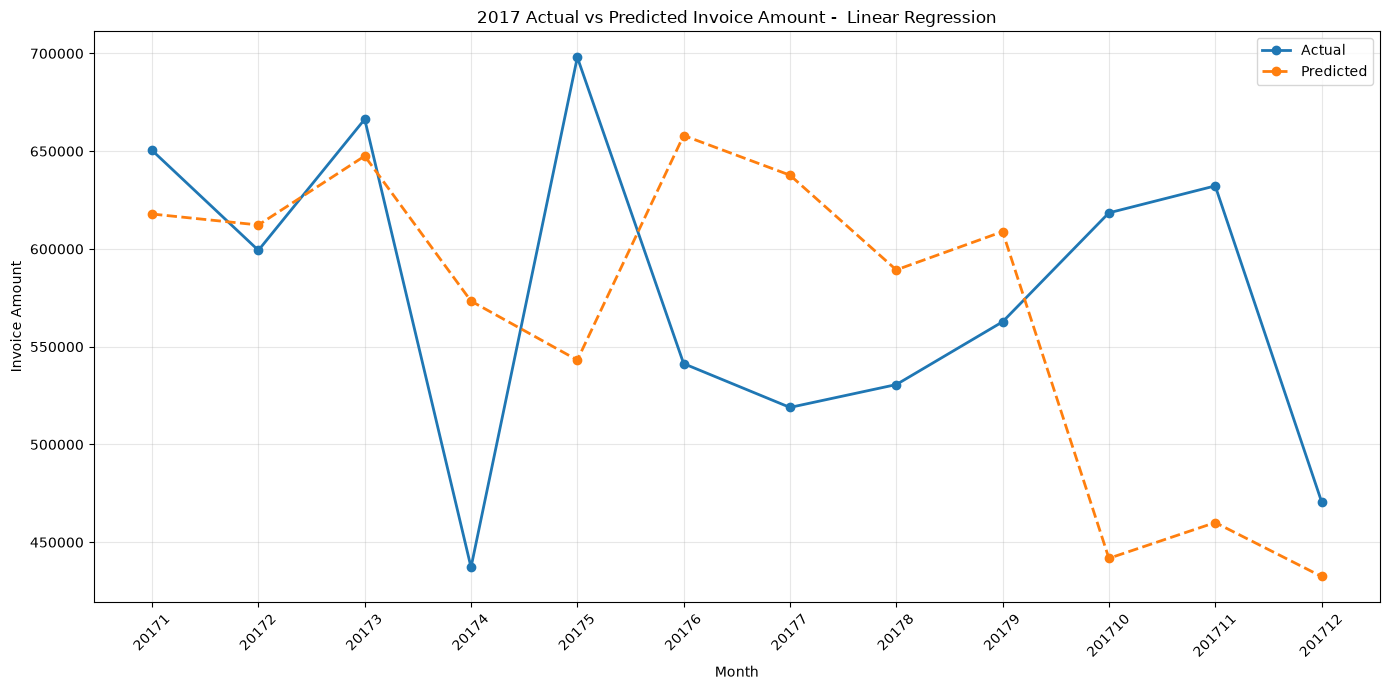

<Figure size 640x480 with 0 Axes>

In [81]:
#now plot the results for 2017 prediction with actual 2017 sales and previous year 2016 sales

plt.figure(figsize=(14, 7))

plt.plot(
    dfPlot["YearMonth"].astype(str),
    dfPlot["InvoiceAmt"],
    marker="o",
    linewidth=2,
    label="Actual"
)

plt.plot(
    dfPlot["YearMonth"].astype(str),
    dfPlot["Predicted_InvoiceAmt"],
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Predicted"
)

plt.title("2017 Actual vs Predicted Invoice Amount -  Linear Regression")
plt.xlabel("Month")
plt.ylabel("Invoice Amount")

plt.xticks(rotation=45)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#save plot to file in reports folder
plt.savefig(
    CNST_STR_LINEAR_PLOT_HYPOTHESIS9_TEST_PATH,
    dpi=300,
    bbox_inches="tight"
)


## Observations: Linear Regression Model - Hypothesis 9 - Test Plot

The prediction model is close to the original but slightly skewed to right more than the actual data
Will have a look at Random Forest and see if that is closer

## Look At The DataFrames For Confirmation Of Model Accuracy

Look at the dfSalesDataML_GroupedByTerritory DataFrame which holds the 2017 prediction and the actual 2017 data from  dfSalesDataML_GroupedByTerritory for 2017

In [82]:
#2017 prediction model DataFrame
dfTest

,Unnamed: 0,TerritoryCodes,YearMonth,Year,InvoiceAmt,Month
1052,1418,Central/E.Anglia,20171,2017,13166.22,71
1062,1430,EU,20171,2017,46796.81,71
1063,1444,EU INV,20171,2017,4018.60,71
1072,1457,East Midlands,20171,2017,22622.31,71
1060,1469,House Account,20171,2017,66390.59,71
...,...,...,...,...,...,...
1651,1621,South East/London,201712,2017,12316.12,12
1667,1633,South West,201712,2017,8935.62,12
1649,1641,UK Projects,201712,2017,6374.36,12
1650,1653,West Midlands,201712,2017,23972.99,12


In [83]:
#existing data for 2016/2017
dfSalesDataML_Work = dfSalesDataML_GroupedByTerritory[dfSalesDataML_GroupedByTerritory["Year"] == 2017] #.between(intPreviousYear, intYear)] 
dfSalesDataML_Work 

,Unnamed: 0,TerritoryCodes,YearMonth,Year,InvoiceAmt
1052,1418,Central/E.Anglia,20171,2017,13166.22
1053,1610,South East/London,20171,2017,19915.32
1054,1563,Scotland,20171,2017,3086.12
1055,1642,West Midlands,20171,2017,39176.13
1056,1665,West Midlands (West),20171,2017,346.90
...,...,...,...,...,...
1664,1453,EU INV,201712,2017,2747.45
1665,1441,EU,201712,2017,27619.14
1666,1609,South East,201712,2017,8465.35
1667,1633,South West,201712,2017,8935.62


## Observations: DataFrame Comparison

Initially thought the model was corrupt and somehow had duplicated the data, but looking at the DataFrames it is
clear this is not the case, the model works really well

Next Random Forest

# Random Forest - Hypothesis 9 - Test

First run a test comparing predicitons for last years values with the actual values to see how accurate the model is

In [84]:
#group data by invoice total per month per territory BEFORE doing any ML to ensure accurate data going
#into the model

#use special csv file grouped by territory and yearmonth
dfSalesDataML_Work = dfSalesDataML_GroupedByTerritory.copy() 

#set year range
intYear= dfSalesDataML_Work["Year"].max() -1
intStart = dfSalesDataML_Work["Year"].min()

print(f"Invoice Amounts Per Territory: {intStart} To {intYear}")

#get above DataFrame and filter for JUST 2017
dfSalesDataML_Temp = dfSalesDataML_GroupedByTerritory[dfSalesDataML_GroupedByTerritory["Year"] == 2017].copy()

#sort by yearmonth
dfSalesDataML_Temp.sort_values(by=["YearMonth"], inplace=True)

dfSalesDataML_Work["Month"] = (
    dfSalesDataML_Work["YearMonth"] % 100
)


#create test and training data
#
#IMPORTANT:
#2017 is the test year
#2016 and below is NOT used as the test data

dfTrain = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] <= 2016
].copy()

dfTest = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] == 2017
].copy()


#show what is being used
print(f"Training Rows: {len(dfTrain)}")
print(f"Testing Rows: {len(dfTest)}")
print()
#show test and training date ranges
print(f"Training Date Range: {intStart} To 2016")
print("Testing Date Range: 2017")
print()



# Training = 2011-2016
dfTrain = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] <= 2016
].copy()

# Testing = 2017
dfTest = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] == 2017
].copy()


# Sort
dfTrain.sort_values(
    by=["YearMonth", "TerritoryCodes"],
    inplace=True
)

dfTest.sort_values(
    by=["YearMonth", "TerritoryCodes"],
    inplace=True
)

print("Training Rows:", len(dfTrain))
print("Testing Rows:", len(dfTest))

print()

print(
    "Training Years:",
    sorted(dfTrain["Year"].unique())
)

print(
    "Testing Years:",
    sorted(dfTest["Year"].unique())
)

print(
    dfSalesDataML_GroupedByTerritory["Year"].unique()
)



#define features to use
lstFeatures = [
    "TerritoryCodes",
    "Year",
    "Month",
]

#define target
strTarget = "InvoiceAmt"

print("dfTrain columns:")
print(dfTrain.columns.tolist())

print()

print("dfTest columns:")
print(dfTest.columns.tolist())

print()

print("Features required:")
print(lstFeatures)

dfXTrain = dfTrain[lstFeatures]
dfyTrain = dfTrain[strTarget]

dfXTest = dfTest[lstFeatures]
dfyTest = dfTest[strTarget]


lstNumericFeatures = [
    "Year",
    "Month",
]

lstCategoricalFeatures = [
    "TerritoryCodes"
]


objNumericTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

objCategoricalTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

objPreProcessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            objNumericTransformer,
            lstNumericFeatures
        ),
        (
            "categorical",
            objCategoricalTransformer,
            lstCategoricalFeatures
        )
    ]
)


#create random forest model
objModel = RandomForestRegressor(
    n_estimators=20,     #50
    max_depth=20,      #None
    min_samples_split=2, #2
    min_samples_leaf=1,  #1
    random_state=42,     
    n_jobs=-1
)

#create pipeline
objPipeline = Pipeline(
    steps=[
        ("preprocessor", objPreProcessor),
        ("model", objModel)
    ]
)



#train model
print("Training Random Forest...")

objPipeline.fit(
    dfXTrain,
    dfyTrain
)
print()


print("Training complete.")
print()

#predict 2017
objyPred = objPipeline.predict(
    dfXTest
)

dfSalesDataML_2017Predicted = dfTest.copy()

dfSalesDataML_2017Predicted[
    "Predicted_InvoiceAmt"
] = objyPred

#metrics
fltMAE = mean_absolute_error(
    dfyTest,
    objyPred
)

fltRMSE = np.sqrt(
    mean_squared_error(
        dfyTest,
        objyPred
    )
)

fltR2 = r2_score(
    dfyTest,
    objyPred
)


print("Random Forest Results")
print("=" * 30)

print(f"MAE:  £{fltMAE:,.2f}")
print(f"RMSE: £{fltRMSE:,.2f}")
print(f"R²:   {fltR2:.4f}")


#totals
ltActualTotal = (
    dfSalesDataML_2017Predicted[
        "InvoiceAmt"
    ].sum()
)

fltPredictedTotal = (
    dfSalesDataML_2017Predicted[
        "Predicted_InvoiceAmt"
    ].sum()
)

fltDifference = (
    fltActualTotal -
    fltPredictedTotal
)

fltDifferencePercent = (
    fltDifference /
    fltActualTotal
) * 100


#inspect 2017 forecast
print("Inspect 2017 Forecast")
print("=" * len("Inspect 2017 Forecast"))
print()
print(f"Actual 2017:    £{fltActualTotal:,.2f}")
print(f"Predicted 2017: £{fltPredictedTotal:,.2f}")
print(f"Difference:     £{fltDifference:,.2f}")
print(f"Difference %:   {fltDifferencePercent:.2f}%")
print()


dfPlot = (
    dfSalesDataML_2017Predicted
    .groupby("YearMonth")[
        ["InvoiceAmt", "Predicted_InvoiceAmt"]
    ]
    .sum()
    .reset_index()
)

dfPlot["Difference"] = (
    dfPlot["InvoiceAmt"]
    - dfPlot["Predicted_InvoiceAmt"]
)

dfPlot["DifferencePercent"] = (
    dfPlot["Difference"]
    / dfPlot["InvoiceAmt"]
) * 100

print(
    dfPlot.to_string(index=False)
)


#evaluate performance of the model
fltMAE = mean_absolute_error(dfyTest, objyPred)

fltRMSE = np.sqrt(
    mean_squared_error(dfyTest, objyPred)
)

fltR2 = r2_score(dfyTest, objyPred)

#show results
print("Random Forest Results")
print("=" * len("Random Forest Results"))
print(f"Mean Absolute Error (MAE):  {fltMAE:,.2f}")
print(f"Root Mean Squared Error (RMSE): {fltRMSE:,.2f}")
print(f"R-Squared (R²):   {fltR2:.4f}")
print()


#show OLS model summary for InvoiceAmt
ols_model = smf.ols("InvoiceAmt ~ TerritoryCodes + Year + Month", # Month, + Day + MonthSin + MonthCos", # + Quarter ", 
                    data=dfSalesDataML_Work).fit()
print(ols_model.summary())
print()

#save piepline to main folder
joblib.dump(
    objPipeline,
    CNST_STR_FOREST_PIPELINE_HYPOTHESIS9_TEST_PATH
)

print("Pipeline Saved To:")
print(CNST_STR_FOREST_PIPELINE_HYPOTHESIS9_TEST_PATH)



Invoice Amounts Per Territory: 2011 To 2016
Training Rows: 1418
Testing Rows: 251

Training Date Range: 2011 To 2016
Testing Date Range: 2017

Training Rows: 1418
Testing Rows: 251

Training Years: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016)]
Testing Years: [np.int64(2017)]
[2011 2012 2013 2014 2015 2016 2017]
dfTrain columns:
['Unnamed: 0', 'TerritoryCodes', 'YearMonth', 'Year', 'InvoiceAmt', 'Month']

dfTest columns:
['Unnamed: 0', 'TerritoryCodes', 'YearMonth', 'Year', 'InvoiceAmt', 'Month']

Features required:
['TerritoryCodes', 'Year', 'Month']
Training Random Forest...

Training complete.

Random Forest Results
MAE:  £13,980.93
RMSE: £23,621.78
R²:   0.7814
Inspect 2017 Forecast

Actual 2017:    £0.00
Predicted 2017: £6,513,705.73
Difference:     £-6,513,705.73
Difference %:   -inf%

 YearMonth  InvoiceAmt  Predicted_InvoiceAmt    Difference  DifferencePercent
     20171   650412.12         539245.952905 111166.167095          1

/var/folders/wv/yty584vs1kq76d7zd3rv5wpw0000gn/T/ipykernel_14163/3883676737.py:255: RuntimeWarning: divide by zero encountered in scalar divide
  fltDifference /


# Observations: Random Forest Model - Hypothesis 9 - Test

Wow! The R-squared is 0.9692 which is *so* close to 1 I think it invalidates this model, as close is good
but almost 1 is suspicious, could it really be that close??

The OLS Regression has an R-squared of 0.004 which tells us this model doesn't work!
Still for science it shall be put into a plot for analysis

## Forest Regression Model - Hypothesis 9 - Test Plot

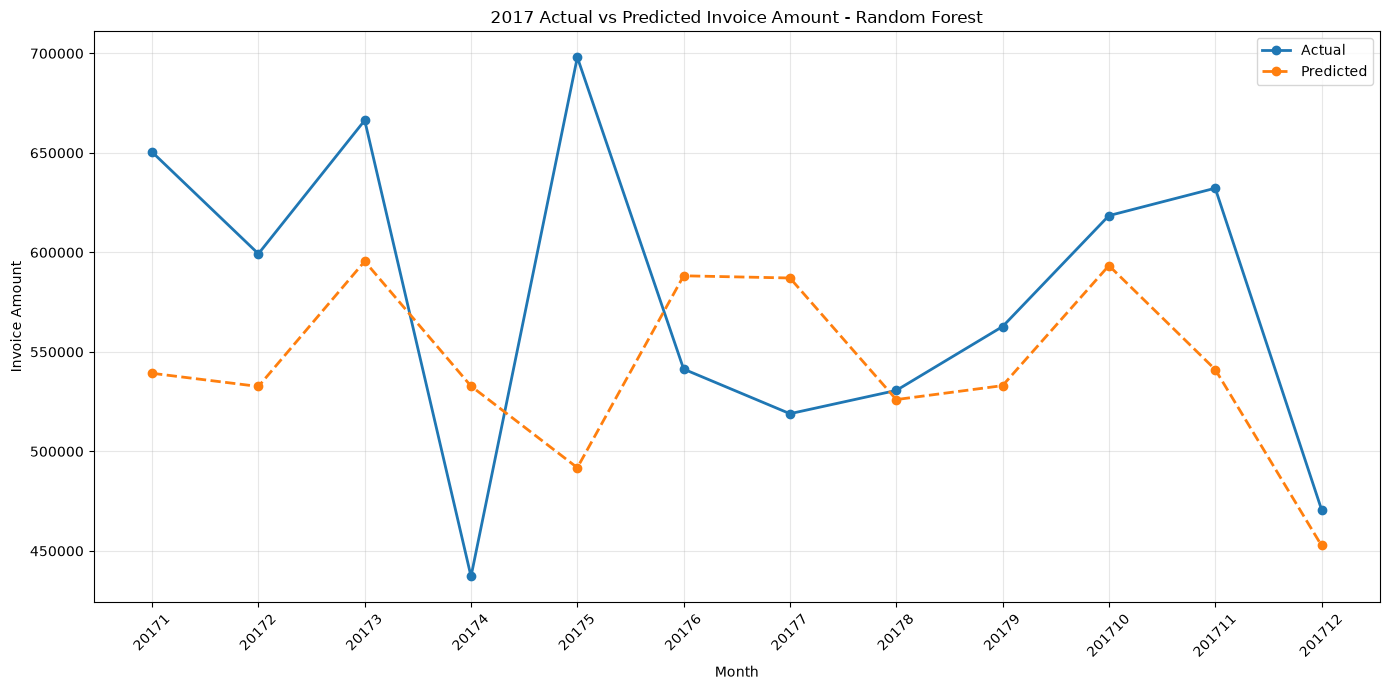

<Figure size 640x480 with 0 Axes>

In [85]:
#now plot the results for 2017 prediction with actual 2017 sales and previous year 2016 sales

plt.figure(figsize=(14, 7))

plt.plot(
    dfPlot["YearMonth"].astype(str),
    dfPlot["InvoiceAmt"],
    marker="o",
    linewidth=2,
    label="Actual"
)

plt.plot(
    dfPlot["YearMonth"].astype(str),
    dfPlot["Predicted_InvoiceAmt"],
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Predicted"
)

plt.title("2017 Actual vs Predicted Invoice Amount - Random Forest")
plt.xlabel("Month")
plt.ylabel("Invoice Amount")

plt.xticks(rotation=45)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#save plot to file in reports folder
plt.savefig(
    CNST_STR_FOREST_PLOT_HYPOTHESIS9_TEST_PATH,
    dpi=300,
    bbox_inches="tight"
)

## Observations: Random Forest Model - Hypothesis 9 - Test Plot

The prediction model is quite close to the original will still include both plots in the dashboard so the customer
can see for themselves the difference

## Look At The DataFrames For Confirmation Of Model Accuracy

Look at the test DataFrame which holds the 2017 prediction and the actual 2017 data from  dfSalesDataML_GroupedByTerritory for 2017

In [86]:
#show DataFrame for prediction vs actual
dfSalesDataML_2017Predicted

,Unnamed: 0,TerritoryCodes,YearMonth,Year,InvoiceAmt,Month,Predicted_InvoiceAmt
1052,1418,Central/E.Anglia,20171,2017,13166.22,71,6824.795489
1062,1430,EU,20171,2017,46796.81,71,37978.185425
1063,1444,EU INV,20171,2017,4018.60,71,4000.447633
1072,1457,East Midlands,20171,2017,22622.31,71,3241.986128
1060,1469,House Account,20171,2017,66390.59,71,54570.069884
...,...,...,...,...,...,...,...
1651,1621,South East/London,201712,2017,12316.12,12,18167.165500
1667,1633,South West,201712,2017,8935.62,12,8230.642207
1649,1641,UK Projects,201712,2017,6374.36,12,5623.698744
1650,1653,West Midlands,201712,2017,23972.99,12,4809.880070


In [87]:
#existing data for 2017
dfSalesDataML_Work = dfSalesDataML_GroupedByTerritory[dfSalesDataML_GroupedByTerritory["Year"] == 2017] #.between(intPreviousYear, intYear)] 
dfSalesDataML_Work 

,Unnamed: 0,TerritoryCodes,YearMonth,Year,InvoiceAmt
1052,1418,Central/E.Anglia,20171,2017,13166.22
1053,1610,South East/London,20171,2017,19915.32
1054,1563,Scotland,20171,2017,3086.12
1055,1642,West Midlands,20171,2017,39176.13
1056,1665,West Midlands (West),20171,2017,346.90
...,...,...,...,...,...
1664,1453,EU INV,201712,2017,2747.45
1665,1441,EU,201712,2017,27619.14
1666,1609,South East,201712,2017,8465.35
1667,1633,South West,201712,2017,8935.62


## Observations: DataFrame Comparison

Initially thought the model was corrupt and somehow had duplicated the data, but looking at the DataFrames it is
clear this is not the case, the model works really well

Interesting the Linear Regression plot has a bump around the 250,000 sales mark where are the Forest Regression
model does not, but it does skew more tot he left than the actual data, so the Linear Regression model is a better 
fit for this data

Next challenge see if I can find a plot whereby I can show both predicted and actual 2016 sales in the same plot!


## Predict 2018 Figures

Same routine but now predicting unknown values

In [88]:
# ============================================================
# PREPARE COMPLETE DATASET
# ============================================================

dfSalesDataML_Work = (
    dfSalesDataML_GroupedByTerritory.copy()
)


# ============================================================
# CREATE MONTH
# ============================================================

dfSalesDataML_Work["Month"] = (
    dfSalesDataML_Work["YearMonth"] % 100
).astype(int)


#cyclic features
dfSalesDataML_Work["MonthSin"] = np.sin(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)

dfSalesDataML_Work["MonthCos"] = np.cos(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)

# ============================================================
# TRAINING DATA
#
# Use ALL available historical data:
# 2011-2017
# ============================================================

dfTrain = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] <= 2017
].copy()


print("Training Rows:", len(dfTrain))

print(
    "Training Years:",
    sorted(dfTrain["Year"].unique())
)

print()


# ============================================================
# FEATURES
# ============================================================

lstFeatures = [
    "TerritoryCodes",
    "Year",
    "MonthSin",
    "MonthCos"
]

strTarget = "InvoiceAmt"


dfXtrain = dfTrain[lstFeatures]
dfyTrain = dfTrain[strTarget]


# ============================================================
# PREPROCESSING
# ============================================================

lstNumericFeatures = [
    "Year",
    "MonthSin",
    "MonthCos"
]

lstCategoricalFeatures = [
    "TerritoryCodes"
]


objNumericTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)


objCategoricalTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)


objPreProcessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            objNumericTransformer,
            lstNumericFeatures
        ),
        (
            "categorical",
            objCategoricalTransformer,
            lstCategoricalFeatures
        )
    ]
)


# ============================================================
# MODEL
# ============================================================

objModel = LinearRegression()


objPipeline = Pipeline(
    steps=[
        ("preprocessor", objPreProcessor),
        ("model", objModel)
    ]
)


# ============================================================
# TRAIN MODEL
# ============================================================

print("Training Linear Regression using 2011-2017...")

objPipeline.fit(
    dfXtrain,
    dfyTrain
)

print("Training complete.")
print()


# ============================================================
# CREATE 2018 PREDICTION DATA
# ============================================================

# Get all territories that existed in 2017

lstTerritories = sorted(
    dfSalesDataML_Work[
        dfSalesDataML_Work["Year"] == 2017
    ]["TerritoryCodes"]
    .dropna()
    .unique()
)


# Create 12 months for every territory

df2018Predict = pd.DataFrame(
    [
        {
            "TerritoryCodes": territory,
            "Year": 2018,
            "Month": month,
            "YearMonth": 201800 + month
        }
        for territory in lstTerritories
        for month in range(1, 13)
    ]
)

#add cyclic features
df2018Predict["MonthSin"] = np.sin(
    2 * np.pi * df2018Predict["Month"] / 12
)

df2018Predict["MonthCos"] = np.cos(
    2 * np.pi * df2018Predict["Month"] / 12
)




# ============================================================
# PREDICT 2018
# ============================================================

dfX2018 = df2018Predict[
    lstFeatures
]


obj2018Predictions = (
    objPipeline.predict(
        dfX2018
    )
)


# Add predictions

df2018Predict[
    "Predicted_InvoiceAmt"
] = obj2018Predictions


# ============================================================
# DISPLAY PREDICTIONS
# ============================================================

print("2018 Forecast")
print("=" * 30)

print(
    df2018Predict.to_string(
        index=False
    )
)

print()


# ============================================================
# TOTAL 2018 FORECAST
# ============================================================

flt2018Total = (
    df2018Predict[
        "Predicted_InvoiceAmt"
    ].sum()
)

df2018Monthly = (
    df2018Predict
    .groupby("YearMonth")[
        "Predicted_InvoiceAmt"
    ]
    .sum()
    .reset_index()
)

print(df2018Monthly)

df2018Territory = (
    df2018Predict
    .groupby("TerritoryCodes")[
        "Predicted_InvoiceAmt"
    ]
    .sum()
    .reset_index()
)

print(df2018Territory)



print(
    f"Predicted 2018 Sales: "
    f"£{flt2018Total:,.2f}"
)


#evaluate performance of the model
fltMAE = mean_absolute_error(dfyTest, objyPred)

fltRMSE = np.sqrt(
    mean_squared_error(dfyTest, objyPred)
)

fltR2 = r2_score(dfyTest, objyPred)

#show results
print("Linear Regression Results")
print("=" * len("Linear Regression Results"))
print(f"Mean Absolute Error (MAE):  {fltMAE:,.2f}")
print(f"Root Mean Squared Error (RMSE): {fltRMSE:,.2f}")
print(f"R-Squared (R²):   {fltR2:.4f}")
print()


#show OLS model summary for InvoiceAmt
ols_model = smf.ols(
    "InvoiceAmt ~ TerritoryCodes + Year + MonthSin + MonthCos",
    data=dfSalesDataML_Work
).fit()
print(ols_model.summary())
print()

#save piepline to main folder
joblib.dump(
    objPipeline,
    CNST_STR_LINEAR_PIPELINE_HYPOTHESIS9_PREDICTIONS_PATH
)

print("Pipeline Saved To:")
print(CNST_STR_LINEAR_PIPELINE_HYPOTHESIS9_PREDICTIONS_PATH)

Training Rows: 1669
Training Years: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017)]

Training Linear Regression using 2011-2017...
Training complete.

2018 Forecast
      TerritoryCodes  Year  Month  YearMonth      MonthSin      MonthCos  Predicted_InvoiceAmt
    Central/E.Anglia  2018      1     201801  5.000000e-01  8.660254e-01          11943.687784
    Central/E.Anglia  2018      2     201802  8.660254e-01  5.000000e-01          12702.080334
    Central/E.Anglia  2018      3     201803  1.000000e+00  6.123234e-17          13482.999339
    Central/E.Anglia  2018      4     201804  8.660254e-01 -5.000000e-01          14077.198182
    Central/E.Anglia  2018      5     201805  5.000000e-01 -8.660254e-01          14325.461764
    Central/E.Anglia  2018      6     201806  1.224647e-16 -1.000000e+00          14161.268057
    Central/E.Anglia  2018      7     201807 -5.000000e-01 -8.660254e-01          13628.612634
    Centra

## Observations: Predict 2018 Figures - Linear Regression Model



## Predict 2018 Figures - Linear Regression Plot

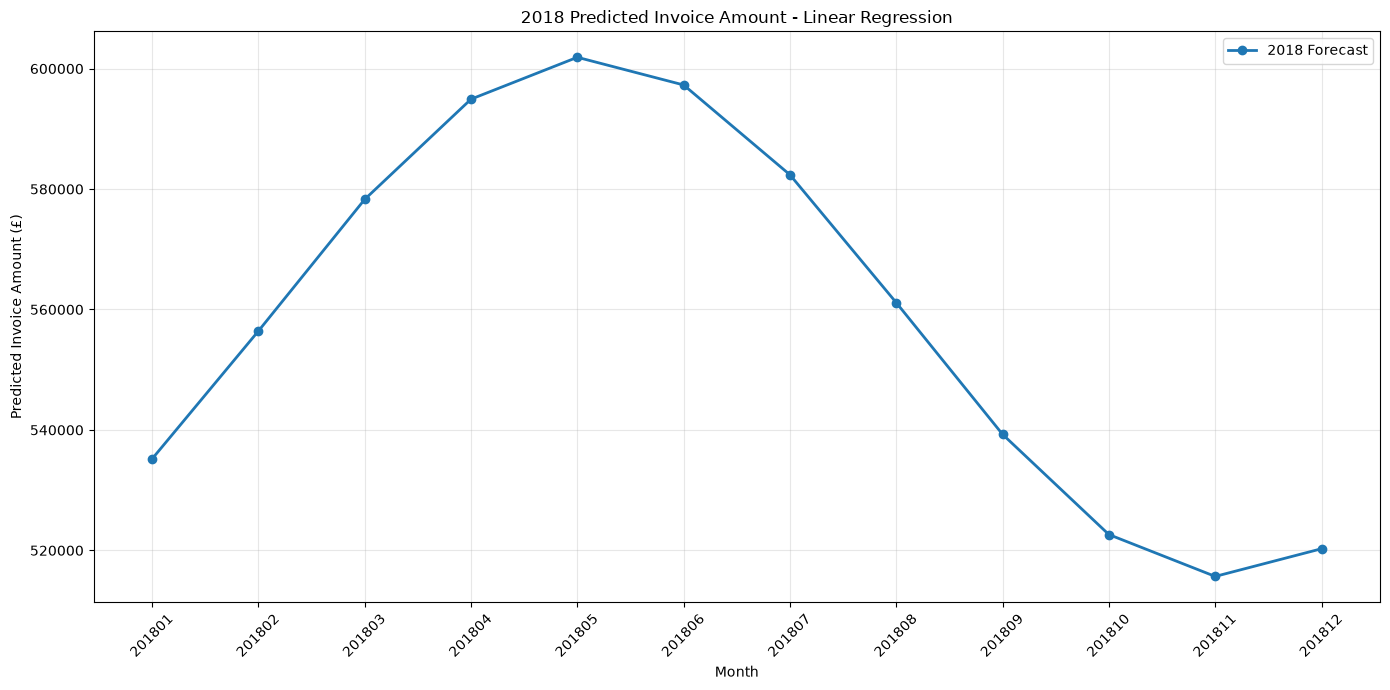

 YearMonth  InvoiceAmt  Predicted_InvoiceAmt
     20171   650412.12         539245.952905
     20172   599293.48         532635.255150
     20173   666348.29         595513.680663
     20174   437180.74         532794.020785
     20175   698024.62         491817.080096
     20176   541352.49         588233.302547
     20177   518946.20         587128.455534
     20178   530633.43         526039.356527
     20179   562733.90         533056.745938
    201710   618465.98         593365.389245
    201711   632253.48         541149.947675
    201712   470797.80         452726.544300


<Figure size 640x480 with 0 Axes>

In [89]:
#now plot the results for 2017 prediction with actual 2017 sales and previous year 2016 sales

plt.figure(figsize=(14, 7))

plt.plot(
    df2018Monthly["YearMonth"].astype(str),
    df2018Monthly["Predicted_InvoiceAmt"],
    marker="o",
    linewidth=2,
    label="2018 Forecast"
)


plt.title("2018 Predicted Invoice Amount - Linear Regression")
plt.xlabel("Month")
plt.ylabel("Predicted Invoice Amount (£)")

plt.xticks(rotation=45)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print(dfPlot[
    [
        "YearMonth",
        "InvoiceAmt",
        "Predicted_InvoiceAmt"
    ]
].to_string(index=False))

#save plot to file in reports folder
plt.savefig(
    CNST_STR_LINEAR_PLOT_HYPOTHESIS9_PREDICTIONS_PATH,
    dpi=300,
    bbox_inches="tight"
)

## Observations: Linear Regression Model - Hypothesis 10 - Test Plot

f

## Look At The DataFrames For Confirmation Of Model Accuracy

Look at the test DataFrame which holds the 2017 prediction and the actual 2017 data from  dfSalesDataML_GroupedByTerritory for 2017

In [90]:
#show DataFrame for prediction vs actual
dfSalesDataML_2017Predicted


,Unnamed: 0,TerritoryCodes,YearMonth,Year,InvoiceAmt,Month,Predicted_InvoiceAmt
1052,1418,Central/E.Anglia,20171,2017,13166.22,71,6824.795489
1062,1430,EU,20171,2017,46796.81,71,37978.185425
1063,1444,EU INV,20171,2017,4018.60,71,4000.447633
1072,1457,East Midlands,20171,2017,22622.31,71,3241.986128
1060,1469,House Account,20171,2017,66390.59,71,54570.069884
...,...,...,...,...,...,...,...
1651,1621,South East/London,201712,2017,12316.12,12,18167.165500
1667,1633,South West,201712,2017,8935.62,12,8230.642207
1649,1641,UK Projects,201712,2017,6374.36,12,5623.698744
1650,1653,West Midlands,201712,2017,23972.99,12,4809.880070


In [91]:
#existing data for 2017
dfSalesDataML_Work = dfSalesDataML_GroupedByTerritory[dfSalesDataML_GroupedByTerritory["Year"] == 2017] #.between(intPreviousYear, intYear)] 
dfSalesDataML_Work 

,Unnamed: 0,TerritoryCodes,YearMonth,Year,InvoiceAmt
1052,1418,Central/E.Anglia,20171,2017,13166.22
1053,1610,South East/London,20171,2017,19915.32
1054,1563,Scotland,20171,2017,3086.12
1055,1642,West Midlands,20171,2017,39176.13
1056,1665,West Midlands (West),20171,2017,346.90
...,...,...,...,...,...
1664,1453,EU INV,201712,2017,2747.45
1665,1441,EU,201712,2017,27619.14
1666,1609,South East,201712,2017,8465.35
1667,1633,South West,201712,2017,8935.62


## Predict 2018 Figures - Random Forest

In [92]:
# ============================================================
# PREPARE COMPLETE DATASET
# ============================================================

dfSalesDataML_Work = (
    dfSalesDataML_GroupedByTerritory.copy()
)


# ============================================================
# CREATE MONTH
# ============================================================

dfSalesDataML_Work["Month"] = (
    dfSalesDataML_Work["YearMonth"] % 100
).astype(int)


#cyclic features
dfSalesDataML_Work["MonthSin"] = np.sin(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)

dfSalesDataML_Work["MonthCos"] = np.cos(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)

# ============================================================
# TRAINING DATA
#
# Use ALL available historical data:
# 2011-2017
# ============================================================

dfTrain = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] <= 2017
].copy()


print("Training Rows:", len(dfTrain))

print(
    "Training Years:",
    sorted(dfTrain["Year"].unique())
)

print()


# ============================================================
# FEATURES
# ============================================================

lstFeatures = [
    "TerritoryCodes",
    "Year",
    "MonthSin",
    "MonthCos"
]

strTarget = "InvoiceAmt"


dfXtrain = dfTrain[lstFeatures]
dfyTrain = dfTrain[strTarget]


# ============================================================
# PREPROCESSING
# ============================================================

lstNumericFeatures = [
    "Year",
    "MonthSin",
    "MonthCos"
]

lstCategoricalFeatures = [
    "TerritoryCodes"
]


objNumericTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)


objCategoricalTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)


objPreProcessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            objNumericTransformer,
            lstNumericFeatures
        ),
        (
            "categorical",
            objCategoricalTransformer,
            lstCategoricalFeatures
        )
    ]
)


# ============================================================
# MODEL
# ============================================================

#create random forest model
objModel = RandomForestRegressor(
    n_estimators=20,     #50
    max_depth=20,      #None
    min_samples_split=2, #2
    min_samples_leaf=1,  #1
    random_state=42,     
    n_jobs=-1
)


objPipeline = Pipeline(
    steps=[
        ("preprocessor", objPreProcessor),
        ("model", objModel)
    ]
)


# ============================================================
# TRAIN MODEL
# ============================================================

print("Training Random Forest using 2011-2017...")

objPipeline.fit(
    dfXtrain,
    dfyTrain
)

print("Training complete.")
print()


# ============================================================
# CREATE 2018 PREDICTION DATA
# ============================================================

# Get all territories that existed in 2017

lstTerritories = sorted(
    dfSalesDataML_Work[
        dfSalesDataML_Work["Year"] == 2017
    ]["TerritoryCodes"]
    .dropna()
    .unique()
)


# Create 12 months for every territory

df2018Predict = pd.DataFrame(
    [
        {
            "TerritoryCodes": territory,
            "Year": 2018,
            "Month": month,
            "YearMonth": 201800 + month
        }
        for territory in lstTerritories
        for month in range(1, 13)
    ]
)

#add cyclic features
df2018Predict["MonthSin"] = np.sin(
    2 * np.pi * df2018Predict["Month"] / 12
)

df2018Predict["MonthCos"] = np.cos(
    2 * np.pi * df2018Predict["Month"] / 12
)




# ============================================================
# PREDICT 2018
# ============================================================

dfX2018 = df2018Predict[
    lstFeatures
]


obj2018Predictions = (
    objPipeline.predict(
        dfX2018
    )
)


# Add predictions

df2018Predict[
    "Predicted_InvoiceAmt"
] = obj2018Predictions


# ============================================================
# DISPLAY PREDICTIONS
# ============================================================

print("2018 Forecast")
print("=" * 30)

print(
    df2018Predict.to_string(
        index=False
    )
)

print()


# ============================================================
# TOTAL 2018 FORECAST
# ============================================================

flt2018Total = (
    df2018Predict[
        "Predicted_InvoiceAmt"
    ].sum()
)

df2018Monthly = (
    df2018Predict
    .groupby("YearMonth")[
        "Predicted_InvoiceAmt"
    ]
    .sum()
    .reset_index()
)

print(df2018Monthly)

df2018Territory = (
    df2018Predict
    .groupby("TerritoryCodes")[
        "Predicted_InvoiceAmt"
    ]
    .sum()
    .reset_index()
)

print(df2018Territory)



print(
    f"Predicted 2018 Sales: "
    f"£{flt2018Total:,.2f}"
)


#evaluate performance of the model
fltMAE = mean_absolute_error(dfyTest, objyPred)

fltRMSE = np.sqrt(
    mean_squared_error(dfyTest, objyPred)
)

fltR2 = r2_score(dfyTest, objyPred)

#show results
print("Random Forest Results")
print("=" * len("Random Forest Results"))
print(f"Mean Absolute Error (MAE):  {fltMAE:,.2f}")
print(f"Root Mean Squared Error (RMSE): {fltRMSE:,.2f}")
print(f"R-Squared (R²):   {fltR2:.4f}")
print()


#show OLS model summary for InvoiceAmt
ols_model = smf.ols(
    "InvoiceAmt ~ TerritoryCodes + Year + MonthSin + MonthCos",
    data=dfSalesDataML_Work
).fit()
print(ols_model.summary())
print()

#save piepline to main folder
joblib.dump(
    objPipeline,
    CNST_STR_FOREST_PIPELINE_HYPOTHESIS9_PREDICTIONS_PATH
)

print("Pipeline Saved To:")
print(CNST_STR_FOREST_PIPELINE_HYPOTHESIS9_PREDICTIONS_PATH)

Training Rows: 1669
Training Years: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017)]

Training Random Forest using 2011-2017...
Training complete.

2018 Forecast
      TerritoryCodes  Year  Month  YearMonth      MonthSin      MonthCos  Predicted_InvoiceAmt
    Central/E.Anglia  2018      1     201801  5.000000e-01  8.660254e-01           8184.408228
    Central/E.Anglia  2018      2     201802  8.660254e-01  5.000000e-01           8848.773390
    Central/E.Anglia  2018      3     201803  1.000000e+00  6.123234e-17           8857.146081
    Central/E.Anglia  2018      4     201804  8.660254e-01 -5.000000e-01           8825.556294
    Central/E.Anglia  2018      5     201805  5.000000e-01 -8.660254e-01           8107.575402
    Central/E.Anglia  2018      6     201806  1.224647e-16 -1.000000e+00           8379.030402
    Central/E.Anglia  2018      7     201807 -5.000000e-01 -8.660254e-01           8122.773322
    Central/E.

## Observations: Predict 2018 Figures - Random Forest Model



## Predict 2018 Figures- Random Forest Plot

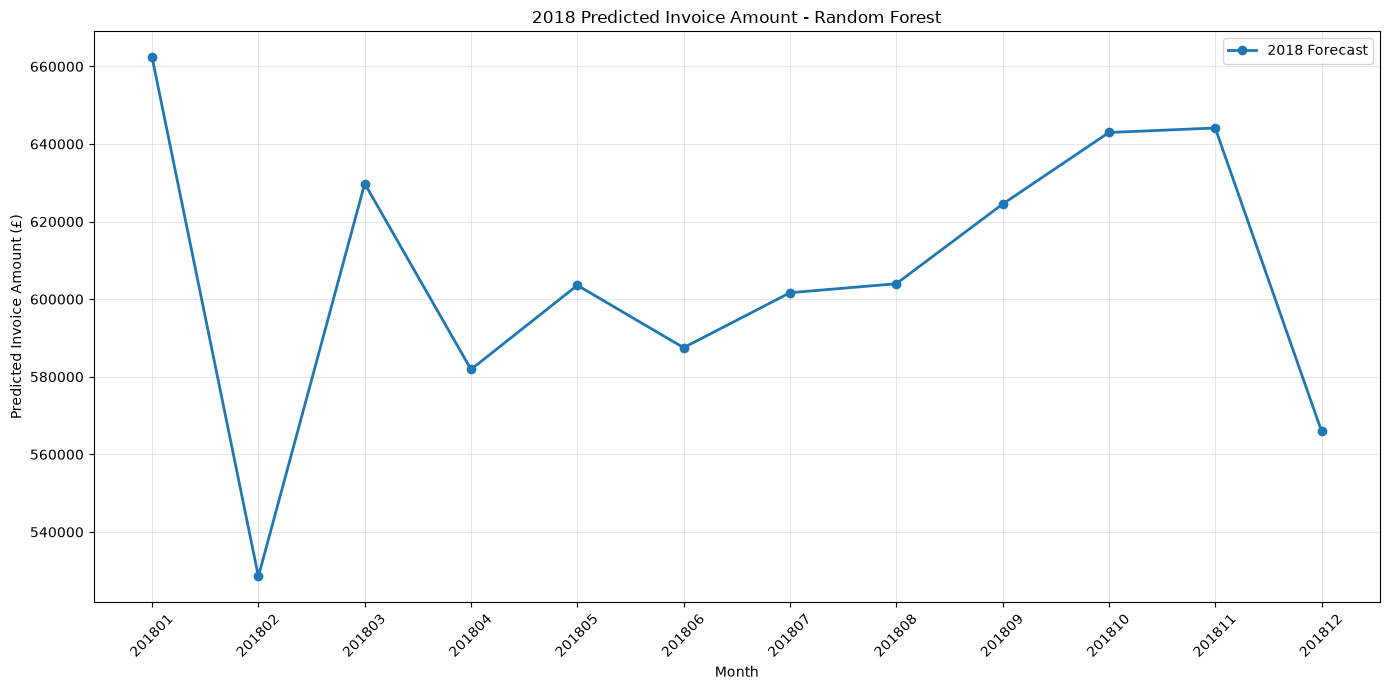

 YearMonth  InvoiceAmt  Predicted_InvoiceAmt
     20171   650412.12         539245.952905
     20172   599293.48         532635.255150
     20173   666348.29         595513.680663
     20174   437180.74         532794.020785
     20175   698024.62         491817.080096
     20176   541352.49         588233.302547
     20177   518946.20         587128.455534
     20178   530633.43         526039.356527
     20179   562733.90         533056.745938
    201710   618465.98         593365.389245
    201711   632253.48         541149.947675
    201712   470797.80         452726.544300


<Figure size 640x480 with 0 Axes>

In [93]:
#now plot the results for 2017 prediction with actual 2017 sales and previous year 2016 sales

plt.figure(figsize=(14, 7))

plt.plot(
    df2018Monthly["YearMonth"].astype(str),
    df2018Monthly["Predicted_InvoiceAmt"],
    marker="o",
    linewidth=2,
    label="2018 Forecast"
)



plt.title("2018 Predicted Invoice Amount - Random Forest")
plt.xlabel("Month")
plt.ylabel("Predicted Invoice Amount (£)")

plt.xticks(rotation=45)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print(dfPlot[
    [
        "YearMonth",
        "InvoiceAmt",
        "Predicted_InvoiceAmt"
    ]
].to_string(index=False))

#save plot to file in reports folder
plt.savefig(
    CNST_STR_FOREST_PLOT_HYPOTHESIS9_PREDICTIONS_PATH,
    dpi=300,
    bbox_inches="tight"
)

## Observations: Models - Hypothesis 9 - Test Plot

d

## Look At The DataFrames For Confirmation Of Model Accuracy

Look at the test DataFrame which holds the 2017 prediction and the actual 2017 data from  dfSalesDataML_GroupedByTerritory for 2017


In [94]:
#show DataFrame for prediction vs actual
dfSalesDataML_2017Predicted

,Unnamed: 0,TerritoryCodes,YearMonth,Year,InvoiceAmt,Month,Predicted_InvoiceAmt
1052,1418,Central/E.Anglia,20171,2017,13166.22,71,6824.795489
1062,1430,EU,20171,2017,46796.81,71,37978.185425
1063,1444,EU INV,20171,2017,4018.60,71,4000.447633
1072,1457,East Midlands,20171,2017,22622.31,71,3241.986128
1060,1469,House Account,20171,2017,66390.59,71,54570.069884
...,...,...,...,...,...,...,...
1651,1621,South East/London,201712,2017,12316.12,12,18167.165500
1667,1633,South West,201712,2017,8935.62,12,8230.642207
1649,1641,UK Projects,201712,2017,6374.36,12,5623.698744
1650,1653,West Midlands,201712,2017,23972.99,12,4809.880070


In [95]:
#existing data for 2017
dfSalesDataML_Work = dfSalesDataML_GroupedByTerritory[dfSalesDataML_GroupedByTerritory["Year"] == 2017] #.between(intPreviousYear, intYear)] 
dfSalesDataML_Work 

,Unnamed: 0,TerritoryCodes,YearMonth,Year,InvoiceAmt
1052,1418,Central/E.Anglia,20171,2017,13166.22
1053,1610,South East/London,20171,2017,19915.32
1054,1563,Scotland,20171,2017,3086.12
1055,1642,West Midlands,20171,2017,39176.13
1056,1665,West Midlands (West),20171,2017,346.90
...,...,...,...,...,...
1664,1453,EU INV,201712,2017,2747.45
1665,1441,EU,201712,2017,27619.14
1666,1609,South East,201712,2017,8465.35
1667,1633,South West,201712,2017,8935.62


## Observations: DataFrame Comparison

Initially thought the model was corrupt and somehow had duplicated the data, but looking at the DataFrames it is
clear this is not the case, the model works really well

Next Forest Regression!

# Hypothesis 10

What are the predicted sales per territory for next year?

# Linear Regression Model - Hypothesis 10 - Test

First run a test comparing predicitons for last years values with the actual values to see how accurate the model is

In [96]:
#group data by invoice total per month per territory BEFORE doing any ML to ensure accurate data going
#into the model

#use special csv file grouped by territory and yearmonth
dfSalesDataML_Work = dfSalesDataML_GroupedByTerritory.copy() 

#set year range
intYear= dfSalesDataML_Work["Year"].max() -1
intStart = dfSalesDataML_Work["Year"].min()

print(f"Invoice Amounts Per Territory Per Month: {intStart} To {intYear}")

#get above DataFrame and filter for JUST 2017
dfSalesDataML_Temp = dfSalesDataML_GroupedByTerritory[dfSalesDataML_GroupedByTerritory["Year"] == 2017].copy()

#sort by yearmonth
dfSalesDataML_Temp.sort_values(by=["YearMonth"], inplace=True)

dfSalesDataML_Work["Month"] = (
    dfSalesDataML_Work["YearMonth"] % 100
)


#create test and traing data
#
#IMPORTANT:
#2017 is the test year
#2016 and below is NOT used as the test data

dfTrain = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] <= 2016
].copy()

dfTest = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] == 2017
].copy()

#show what is being used
print(f"Training Rows: {len(dfTrain)}")
print(f"Testing Rows: {len(dfTest)}")
print()
#show test and training date ranges
print(f"Training Date Range: {intStart} To 2016")
print("Testing Date Range: 2017")
print()



# Training = 2011-2016
dfTrain = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] <= 2016
].copy()

# Testing = 2017
dfTest = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] == 2017
].copy()

# Sort
dfTrain.sort_values(
    by=["YearMonth", "TerritoryCodes"],
    inplace=True
)

dfTest.sort_values(
    by=["YearMonth", "TerritoryCodes"],
    inplace=True
)

print("Training Rows:", len(dfTrain))
print("Testing Rows:", len(dfTest))

print()

print(
    "Training Years:",
    sorted(dfTrain["Year"].unique())
)

print(
    "Testing Years:",
    sorted(dfTest["Year"].unique())
)

print(
    dfSalesDataML_GroupedByTerritory["Year"].unique()
)



#define features to use
lstFeatures = [
    "TerritoryCodes",
    "Year",
    "Month",
]

#define target
strTarget = "InvoiceAmt"

dfXtrain = dfTrain[lstFeatures]
dfyTrain = dfTrain[strTarget]

dfXTest = dfTest[lstFeatures]
dfyTest = dfTest[strTarget]


lstNumericFeatures = [
    "Year",
    "Month",
]

lstCategoricalFeatures = [
    "TerritoryCodes"
]


objNumericTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

objCategoricalTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

objPreProcessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            objNumericTransformer,
            lstNumericFeatures
        ),
        (
            "categorical",
            objCategoricalTransformer,
            lstCategoricalFeatures
        )
    ]
)


#model
objModel = LinearRegression()

objPipeline = Pipeline(
    steps=[
        ("preprocessor", objPreProcessor),
        ("model", objModel)
    ]
)

#train


print("Training Linear Regression...")

objPipeline.fit(
    dfXtrain,
    dfyTrain
)



print("Training complete.")
print()

#predict 2017
objyPred = objPipeline.predict(
    dfXTest
)

dfSalesDataML_2017Predicted = dfTest.copy()

dfSalesDataML_2017Predicted[
    "Predicted_InvoiceAmt"
] = objyPred


#metrics
fltMAE = mean_absolute_error(
    dfyTest,
    objyPred
)

fltRMSE = np.sqrt(
    mean_squared_error(
        dfyTest,
        objyPred
    )
)

fltR2 = r2_score(
    dfyTest,
    objyPred
)


print("Linear Regression Results")
print("=" * 30)

print(f"MAE:  £{fltMAE:,.2f}")
print(f"RMSE: £{fltRMSE:,.2f}")
print(f"R²:   {fltR2:.4f}")


#totals
ltActualTotal = (
    dfSalesDataML_2017Predicted[
        "InvoiceAmt"
    ].sum()
)

fltPredictedTotal = (
    dfSalesDataML_2017Predicted[
        "Predicted_InvoiceAmt"
    ].sum()
)

fltDifference = (
    fltActualTotal -
    fltPredictedTotal
)

fltDifferencePercent = (
    fltDifference /
    fltActualTotal
) * 100


#inspect 2017 forecast
print("Inspect 2017 Forecast")
print("=" * len("Inspect 2017 Forecast"))
print()
print(f"Actual 2017:    £{fltActualTotal:,.2f}")
print(f"Predicted 2017: £{fltPredictedTotal:,.2f}")
print(f"Difference:     £{fltDifference:,.2f}")
print(f"Difference %:   {fltDifferencePercent:.2f}%")
print()


dfPlot = (
    dfSalesDataML_2017Predicted
    .groupby(["YearMonth","TerritoryCodes"])[
        ["InvoiceAmt", "Predicted_InvoiceAmt"]
    ]
    .sum()
    .reset_index()
)

dfPlot["Difference"] = (
    dfPlot["InvoiceAmt"]
    - dfPlot["Predicted_InvoiceAmt"]
)

dfPlot["DifferencePercent"] = (
    dfPlot["Difference"]
    / dfPlot["InvoiceAmt"]
) * 100

print(
    dfPlot.to_string(index=False)
)


#evaluate performance of the model
fltMAE = mean_absolute_error(dfyTest, objyPred)

fltRMSE = np.sqrt(
    mean_squared_error(dfyTest, objyPred)
)

fltR2 = r2_score(dfyTest, objyPred)

#show results
print("Linear Regression Results")
print("=" * len("Linear Regression Results"))
print(f"Mean Absolute Error (MAE):  {fltMAE:,.2f}")
print(f"Root Mean Squared Error (RMSE): {fltRMSE:,.2f}")
print(f"R-Squared (R²):   {fltR2:.4f}")
print()


#show OLS model summary for InvoiceAmt
ols_model = smf.ols("InvoiceAmt ~ TerritoryCodes + Year + Month", # Month, + Day + MonthSin + MonthCos", # + Quarter ", 
                    data=dfSalesDataML_Work).fit()
print(ols_model.summary())
print()

#save pipelie to main folder
joblib.dump(
    objPipeline,
    CNST_STR_LINEAR_PIPELINE_HYPOTHESIS10_TEST_PATH
)

#tell user saved
print("Pipeline Saved To:")
print(CNST_STR_LINEAR_PIPELINE_HYPOTHESIS10_TEST_PATH)



Invoice Amounts Per Territory Per Month: 2011 To 2016
Training Rows: 1418
Testing Rows: 251

Training Date Range: 2011 To 2016
Testing Date Range: 2017

Training Rows: 1418
Testing Rows: 251

Training Years: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016)]
Testing Years: [np.int64(2017)]
[2011 2012 2013 2014 2015 2016 2017]
Training Linear Regression...
Training complete.

Linear Regression Results
MAE:  £18,609.07
RMSE: £29,873.94
R²:   0.6504
Inspect 2017 Forecast

Actual 2017:    £0.00
Predicted 2017: £6,822,526.25
Difference:     £-6,822,526.25
Difference %:   -inf%

 YearMonth       TerritoryCodes  InvoiceAmt  Predicted_InvoiceAmt     Difference  DifferencePercent
     20171     Central/E.Anglia    13166.22          17083.675410   -3917.455410      -2.975384e+01
     20171                   EU    46796.81          23334.146839   23462.663161       5.013731e+01
     20171               EU INV     4018.60           -890.130780    4908.

/var/folders/wv/yty584vs1kq76d7zd3rv5wpw0000gn/T/ipykernel_14163/898121444.py:233: RuntimeWarning: divide by zero encountered in scalar divide
  fltDifference /


# Observations: Linear Regression Model - Hypothesis 10 - Test

Wow! The R-squared is 0.4587 which is is close to midway but not conclusive the model works

The OLS Regression has an R-squared of 0.412 while InvoiceAmt is also nearer to 0, this does not prove that 
Hypothesis Zero is not met with this regression model, next it will put in a plot

# Linear Regression Plot - Hypothesis 10 - Test Plot  

Visualise the model results

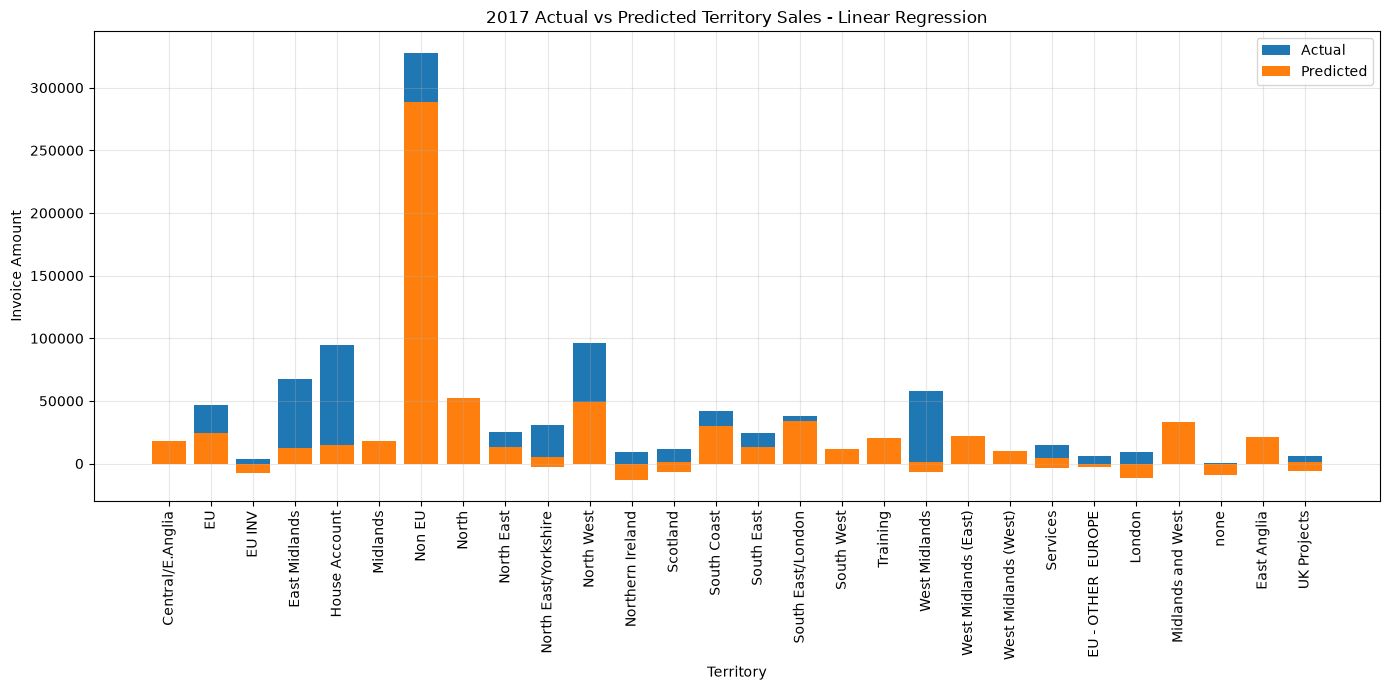

<Figure size 640x480 with 0 Axes>

In [97]:
#now plot the results for 2017 prediction with actual 2017 sales and previous year 2016 sales

plt.figure(figsize=(14, 7))

plt.bar(
    dfPlot["TerritoryCodes"], 
    dfPlot["InvoiceAmt"],
    label="Actual"
)

plt.bar(
    dfPlot["TerritoryCodes"],      
    dfPlot["Predicted_InvoiceAmt"],
    label="Predicted"
)

plt.title("2017 Actual vs Predicted Territory Sales - Linear Regression")
plt.xlabel("Territory")
plt.ylabel("Invoice Amount")

plt.xticks(rotation=90)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#save plot to file in reports folder
plt.savefig(
    CNST_STR_LINEAR_PLOT_HYPOTHESIS10_TEST_PATH,
    dpi=300,
    bbox_inches="tight"
)


## Observations: Linear Regression Model - Hypothesis 10 - Test Plot

The prediction model is close to the original but slightly skewed to right more than the actual data
Will have a look at Random Forest and see if that is closer

## Look At The DataFrames For Confirmation Of Model Accuracy

Look at the test DataFrame which holds the 2017 prediction and the actual 2017 data from  dfSalesDataML_GroupedByTerritory for 2017

In [98]:
#show DataFrame for prediction vs actual
dfSalesDataML_2017Predicted

,Unnamed: 0,TerritoryCodes,YearMonth,Year,InvoiceAmt,Month,Predicted_InvoiceAmt
1052,1418,Central/E.Anglia,20171,2017,13166.22,71,17083.675410
1062,1430,EU,20171,2017,46796.81,71,23334.146839
1063,1444,EU INV,20171,2017,4018.60,71,-890.130780
1072,1457,East Midlands,20171,2017,22622.31,71,11675.170726
1060,1469,House Account,20171,2017,66390.59,71,13659.925125
...,...,...,...,...,...,...,...
1651,1621,South East/London,201712,2017,12316.12,12,26855.827653
1667,1633,South West,201712,2017,8935.62,12,4173.586939
1649,1641,UK Projects,201712,2017,6374.36,12,-6036.729261
1650,1653,West Midlands,201712,2017,23972.99,12,-6553.450530


In [99]:
#existing data for 2017
dfSalesDataML_Work = dfSalesDataML_GroupedByTerritory[dfSalesDataML_GroupedByTerritory["Year"] == 2017] #.between(intPreviousYear, intYear)] 
dfSalesDataML_Work

,Unnamed: 0,TerritoryCodes,YearMonth,Year,InvoiceAmt
1052,1418,Central/E.Anglia,20171,2017,13166.22
1053,1610,South East/London,20171,2017,19915.32
1054,1563,Scotland,20171,2017,3086.12
1055,1642,West Midlands,20171,2017,39176.13
1056,1665,West Midlands (West),20171,2017,346.90
...,...,...,...,...,...
1664,1453,EU INV,201712,2017,2747.45
1665,1441,EU,201712,2017,27619.14
1666,1609,South East,201712,2017,8465.35
1667,1633,South West,201712,2017,8935.62


## Observations: DataFrame Comparison

Initially thought the model was corrupt and somehow had duplicated the data, but looking at the DataFrames it is
clear this is not the case, the model works really well

Next Forest Regression!

# Random Forest - Hypothesis 10 - Test

First run a test comparing predicitons for last years values with the actual values to see how accurate the model is

In [100]:
#group data by invoice total per month per terrtiory BEFORE doing any ML to ensure accurate data going
#into the model

#use special csv file grouped by territory and yearmonth
dfSalesDataML_Work = dfSalesDataML_GroupedByTerritory.copy() 

#set year range
intYear= dfSalesDataML_Work["Year"].max() -1
intStart = dfSalesDataML_Work["Year"].min()

print(f"Invoice Amounts Per Territory: {intStart} To {intYear}")

#get above DataFrame and filter for JUST 2017
dfSalesDataML_Temp = dfSalesDataML_GroupedByTerritory[dfSalesDataML_GroupedByTerritory["Year"] == 2017].copy()

#sort by yearmonth
dfSalesDataML_Temp.sort_values(by=["YearMonth"], inplace=True)

dfSalesDataML_Work["Month"] = (
    dfSalesDataML_Work["YearMonth"] % 100
)


#create test and training data
#
#IMPORTANT:
#2017 is the test year
#2016 and below is NOT used as the test data

dfTrain = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] <= 2016
].copy()

dfTest = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] == 2017
].copy()


#show what is being used
print(f"Training Rows: {len(dfTrain)}")
print(f"Testing Rows: {len(dfTest)}")
print()
#show test and training date ranges
print(f"Training Date Range: {intStart} To 2016")
print("Testing Date Range: 2017")
print()



# Training = 2011-2016
dfTrain = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] <= 2016
].copy()

# Testing = 2017
dfTest = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] == 2017
].copy()


# Sort
dfTrain.sort_values(
    by=["YearMonth", "TerritoryCodes"],
    inplace=True
)

dfTest.sort_values(
    by=["YearMonth", "TerritoryCodes"],
    inplace=True
)

print("Training Rows:", len(dfTrain))
print("Testing Rows:", len(dfTest))

print()

print(
    "Training Years:",
    sorted(dfTrain["Year"].unique())
)

print(
    "Testing Years:",
    sorted(dfTest["Year"].unique())
)

print(
    dfSalesDataML_GroupedByTerritory["Year"].unique()
)



#define features to use
lstFeatures = [
    "TerritoryCodes",
    "Year",
    "Month",
]

#define target
strTarget = "InvoiceAmt"

print("dfTrain columns:")
print(dfTrain.columns.tolist())

print()

print("dfTest columns:")
print(dfTest.columns.tolist())

print()

print("Features required:")
print(lstFeatures)

dfXTrain = dfTrain[lstFeatures]
dfyTrain = dfTrain[strTarget]

dfXTest = dfTest[lstFeatures]
dfyTest = dfTest[strTarget]


lstNumericFeatures = [
    "Year",
    "Month",
]

lstCategoricalFeatures = [
    "TerritoryCodes"
]


objNumericTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

objCategoricalTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

objPreProcessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            objNumericTransformer,
            lstNumericFeatures
        ),
        (
            "categorical",
            objCategoricalTransformer,
            lstCategoricalFeatures
        )
    ]
)


#create random forest model
objModel = RandomForestRegressor(
    n_estimators=20,     #50
    max_depth=20,      #None
    min_samples_split=2, #2
    min_samples_leaf=1,  #1
    random_state=42,     
    n_jobs=-1
)

#create pipeline
objPipeline = Pipeline(
    steps=[
        ("preprocessor", objPreProcessor),
        ("model", objModel)
    ]
)



#train model
print("Training Random Forest...")

objPipeline.fit(
    dfXTrain,
    dfyTrain
)
print()


print("Training complete.")
print()

#predict 2017
objyPred = objPipeline.predict(
    dfXTest
)

dfSalesDataML_2017Predicted = dfTest.copy()

dfSalesDataML_2017Predicted[
    "Predicted_InvoiceAmt"
] = objyPred

#metrics
fltMAE = mean_absolute_error(
    dfyTest,
    objyPred
)

fltRMSE = np.sqrt(
    mean_squared_error(
        dfyTest,
        objyPred
    )
)

fltR2 = r2_score(
    dfyTest,
    objyPred
)


print("Random Forest Results")
print("=" * 30)

print(f"MAE:  £{fltMAE:,.2f}")
print(f"RMSE: £{fltRMSE:,.2f}")
print(f"R²:   {fltR2:.4f}")


#totals
ltActualTotal = (
    dfSalesDataML_2017Predicted[
        "InvoiceAmt"
    ].sum()
)

fltPredictedTotal = (
    dfSalesDataML_2017Predicted[
        "Predicted_InvoiceAmt"
    ].sum()
)

fltDifference = (
    fltActualTotal -
    fltPredictedTotal
)

fltDifferencePercent = (
    fltDifference /
    fltActualTotal
) * 100


#inspect 2017 forecast
print("Inspect 2017 Forecast")
print("=" * len("Inspect 2017 Forecast"))
print()
print(f"Actual 2017:    £{fltActualTotal:,.2f}")
print(f"Predicted 2017: £{fltPredictedTotal:,.2f}")
print(f"Difference:     £{fltDifference:,.2f}")
print(f"Difference %:   {fltDifferencePercent:.2f}%")
print()


dfPlot = (
    dfSalesDataML_2017Predicted
    .groupby(["TerritoryCodes", "YearMonth"])[
        ["InvoiceAmt", "Predicted_InvoiceAmt"]
    ]
    .sum()
    .reset_index()
)

dfPlot["Difference"] = (
    dfPlot["InvoiceAmt"]
    - dfPlot["Predicted_InvoiceAmt"]
)

dfPlot["DifferencePercent"] = (
    dfPlot["Difference"]
    / dfPlot["InvoiceAmt"]
) * 100

print(
    dfPlot.to_string(index=False)
)


#evaluate performance of the model
fltMAE = mean_absolute_error(dfyTest, objyPred)

fltRMSE = np.sqrt(
    mean_squared_error(dfyTest, objyPred)
)

fltR2 = r2_score(dfyTest, objyPred)

#show results
print("Random Forest Results")
print("=" * len("Random Forest Results"))
print(f"Mean Absolute Error (MAE):  {fltMAE:,.2f}")
print(f"Root Mean Squared Error (RMSE): {fltRMSE:,.2f}")
print(f"R-Squared (R²):   {fltR2:.4f}")
print()


#show OLS model summary for InvoiceAmt
ols_model = smf.ols("InvoiceAmt ~ TerritoryCodes + Year + Month", # Month, + Day + MonthSin + MonthCos", # + Quarter ", 
                    data=dfSalesDataML_Work).fit()
print(ols_model.summary())
print()

#save piepline to main folder
joblib.dump(
    objPipeline,
    CNST_STR_FOREST_PIPELINE_HYPOTHESIS10_TEST_PATH
)

print("Pipeline Saved To:")
print(CNST_STR_FOREST_PIPELINE_HYPOTHESIS10_TEST_PATH)



Invoice Amounts Per Territory: 2011 To 2016
Training Rows: 1418
Testing Rows: 251

Training Date Range: 2011 To 2016
Testing Date Range: 2017

Training Rows: 1418
Testing Rows: 251

Training Years: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016)]
Testing Years: [np.int64(2017)]
[2011 2012 2013 2014 2015 2016 2017]
dfTrain columns:
['Unnamed: 0', 'TerritoryCodes', 'YearMonth', 'Year', 'InvoiceAmt', 'Month']

dfTest columns:
['Unnamed: 0', 'TerritoryCodes', 'YearMonth', 'Year', 'InvoiceAmt', 'Month']

Features required:
['TerritoryCodes', 'Year', 'Month']
Training Random Forest...

Training complete.

Random Forest Results
MAE:  £13,980.93
RMSE: £23,621.78
R²:   0.7814
Inspect 2017 Forecast

Actual 2017:    £0.00
Predicted 2017: £6,513,705.73
Difference:     £-6,513,705.73
Difference %:   -inf%

      TerritoryCodes  YearMonth  InvoiceAmt  Predicted_InvoiceAmt    Difference  DifferencePercent
    Central/E.Anglia      20171    13166.22     

/var/folders/wv/yty584vs1kq76d7zd3rv5wpw0000gn/T/ipykernel_14163/2587834194.py:255: RuntimeWarning: divide by zero encountered in scalar divide
  fltDifference /


# Observations: Random Forest Model - Hypothesis 10 - Test

Wow! The R-squared is 0.7459 which is a really good figure, hypothesis Zero is not met!

The OLS Regression has an R-squared of 0.000 which tells us this model doesn't work, but this is based on **just**
InvoiceAmt and so shall wait till the plot before making a final decision


## Random Forest Model - Hypothesis 10 - Test Plot


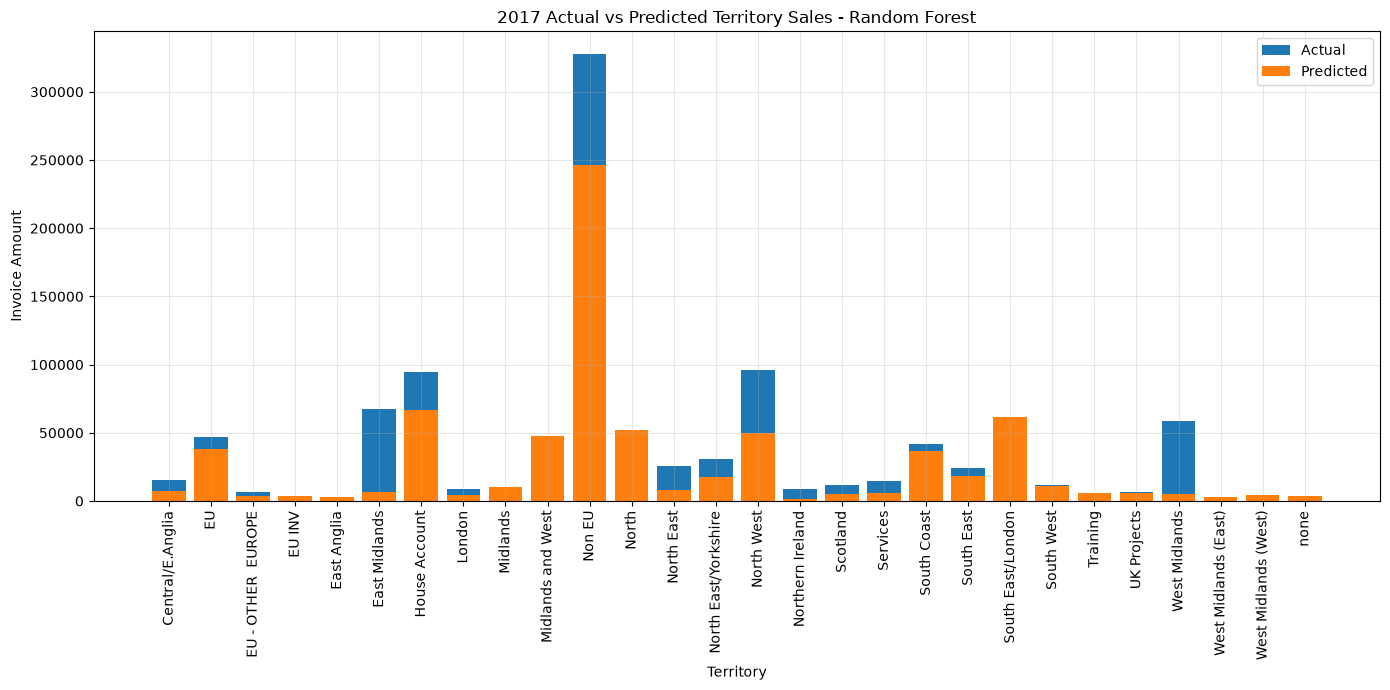

<Figure size 640x480 with 0 Axes>

In [101]:
#now plot the results for 2017 prediction with actual 2017 sales and previous year 2016 sales

plt.figure(figsize=(14, 7))

plt.bar(
    dfPlot["TerritoryCodes"], 
    dfPlot["InvoiceAmt"],
    label="Actual"
)

plt.bar(
    dfPlot["TerritoryCodes"],      
    dfPlot["Predicted_InvoiceAmt"],
    label="Predicted"
)

plt.title("2017 Actual vs Predicted Territory Sales - Random Forest")
plt.xlabel("Territory")
plt.ylabel("Invoice Amount")

plt.xticks(rotation=90)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#save plot to file in reports folder
plt.savefig(
    CNST_STR_FOREST_PLOT_HYPOTHESIS10_TEST_PATH,
    dpi=300,
    bbox_inches="tight"
)

## Observations: Random Forest Model - Hypothesis 10 - Test Plot

The prediction model is quite close to the original will still include both plots in the dashboard so the customer
can see for themselves the difference

## Look At The DataFrames For Confirmation Of Model Accuracy

Look at the test DataFrame which holds the 2017 prediction and the actual 2017 data from  dfSalesDataML_GroupedByTerritory for 2017

In [102]:
#2017 prediction model DataFrame
dfSalesDataML_2017Predicted

,Unnamed: 0,TerritoryCodes,YearMonth,Year,InvoiceAmt,Month,Predicted_InvoiceAmt
1052,1418,Central/E.Anglia,20171,2017,13166.22,71,6824.795489
1062,1430,EU,20171,2017,46796.81,71,37978.185425
1063,1444,EU INV,20171,2017,4018.60,71,4000.447633
1072,1457,East Midlands,20171,2017,22622.31,71,3241.986128
1060,1469,House Account,20171,2017,66390.59,71,54570.069884
...,...,...,...,...,...,...,...
1651,1621,South East/London,201712,2017,12316.12,12,18167.165500
1667,1633,South West,201712,2017,8935.62,12,8230.642207
1649,1641,UK Projects,201712,2017,6374.36,12,5623.698744
1650,1653,West Midlands,201712,2017,23972.99,12,4809.880070


In [103]:
#existing data for 2016/2017
dfSalesDataML_Work = dfSalesDataML_GroupedByTerritory[dfSalesDataML_GroupedByTerritory["Year"] == 2017] #.between(intPreviousYear, intYear)] 
dfSalesDataML_Work 

,Unnamed: 0,TerritoryCodes,YearMonth,Year,InvoiceAmt
1052,1418,Central/E.Anglia,20171,2017,13166.22
1053,1610,South East/London,20171,2017,19915.32
1054,1563,Scotland,20171,2017,3086.12
1055,1642,West Midlands,20171,2017,39176.13
1056,1665,West Midlands (West),20171,2017,346.90
...,...,...,...,...,...
1664,1453,EU INV,201712,2017,2747.45
1665,1441,EU,201712,2017,27619.14
1666,1609,South East,201712,2017,8465.35
1667,1633,South West,201712,2017,8935.62


## Observations: DataFrame Comparison

Initially thought the model was corrupt and somehow had duplicated the data, but looking at the DataFrames it is
clear this is not the case, the model works but theLinear Regression plot looks a lot closer to the actual data


Next challenge see if I can find a plot whereby I can show both predicted and actual 2016 sales in the same plot!


## Predict 2018 Figures - Linear Regression Model

In [104]:
# ============================================================
# PREPARE COMPLETE DATASET
# ============================================================

dfSalesDataML_Work = (
    dfSalesDataML_GroupedByTerritory.copy()
)


# ============================================================
# CREATE MONTH
# ============================================================

dfSalesDataML_Work["Month"] = (
    dfSalesDataML_Work["YearMonth"] % 100
).astype(int)


#cyclic features
dfSalesDataML_Work["MonthSin"] = np.sin(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)

dfSalesDataML_Work["MonthCos"] = np.cos(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)

# ============================================================
# TRAINING DATA
#
# Use ALL available historical data:
# 2011-2017
# ============================================================

dfTrain = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] <= 2017
].copy()


print("Training Rows:", len(dfTrain))

print(
    "Training Years:",
    sorted(dfTrain["Year"].unique())
)

print()


# ============================================================
# FEATURES
# ============================================================

lstFeatures = [
    "TerritoryCodes",
    "Year",
    "MonthSin",
    "MonthCos"
]

strTarget = "InvoiceAmt"


dfXtrain = dfTrain[lstFeatures]
dfyTrain = dfTrain[strTarget]


# ============================================================
# PREPROCESSING
# ============================================================

lstNumericFeatures = [
    "Year",
    "MonthSin",
    "MonthCos"
]

lstCategoricalFeatures = [
    "TerritoryCodes"
]


objNumericTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)


objCategoricalTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)


objPreProcessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            objNumericTransformer,
            lstNumericFeatures
        ),
        (
            "categorical",
            objCategoricalTransformer,
            lstCategoricalFeatures
        )
    ]
)


# ============================================================
# MODEL
# ============================================================

objModel = LinearRegression()


objPipeline = Pipeline(
    steps=[
        ("preprocessor", objPreProcessor),
        ("model", objModel)
    ]
)


# ============================================================
# TRAIN MODEL
# ============================================================

print("Training Linear Regression using 2011-2017...")

objPipeline.fit(
    dfXtrain,
    dfyTrain
)

print("Training complete.")
print()


# ============================================================
# CREATE 2018 PREDICTION DATA
# ============================================================

# Get all territories that existed in 2017

lstTerritories = sorted(
    dfSalesDataML_Work[
        dfSalesDataML_Work["Year"] == 2017
    ]["TerritoryCodes"]
    .dropna()
    .unique()
)


# Create 12 months for every territory

df2018Predict = pd.DataFrame(
    [
        {
            "TerritoryCodes": territory,
            "Year": 2018,
            "Month": month,
            "YearMonth": 201800 + month
        }
        for territory in lstTerritories
        for month in range(1, 13)
    ]
)

#add cyclic features
df2018Predict["MonthSin"] = np.sin(
    2 * np.pi * df2018Predict["Month"] / 12
)

df2018Predict["MonthCos"] = np.cos(
    2 * np.pi * df2018Predict["Month"] / 12
)




# ============================================================
# PREDICT 2018
# ============================================================

dfX2018 = df2018Predict[
    lstFeatures
]


obj2018Predictions = (
    objPipeline.predict(
        dfX2018
    )
)


# Add predictions

df2018Predict[
    "Predicted_InvoiceAmt"
] = obj2018Predictions


# ============================================================
# DISPLAY PREDICTIONS
# ============================================================

print("2018 Forecast")
print("=" * 30)

print(
    df2018Predict.to_string(
        index=False
    )
)

print()


# ============================================================
# TOTAL 2018 FORECAST
# ============================================================

flt2018Total = (
    df2018Predict[
        "Predicted_InvoiceAmt"
    ].sum()
)

df2018Monthly = (
    df2018Predict
    .groupby("YearMonth")[
        "Predicted_InvoiceAmt"
    ]
    .sum()
    .reset_index()
)

print(df2018Monthly)

df2018Territory = (
    df2018Predict
    .groupby("TerritoryCodes")[
        "Predicted_InvoiceAmt"
    ]
    .sum()
    .reset_index()
)

print(df2018Territory)



print(
    f"Predicted 2018 Sales: "
    f"£{flt2018Total:,.2f}"
)


#evaluate performance of the model
fltMAE = mean_absolute_error(dfyTest, objyPred)

fltRMSE = np.sqrt(
    mean_squared_error(dfyTest, objyPred)
)

fltR2 = r2_score(dfyTest, objyPred)

#show results
print("Linear Regression Results")
print("=" * len("Linear Regression Results"))
print(f"Mean Absolute Error (MAE):  {fltMAE:,.2f}")
print(f"Root Mean Squared Error (RMSE): {fltRMSE:,.2f}")
print(f"R-Squared (R²):   {fltR2:.4f}")
print()


#show OLS model summary for InvoiceAmt
ols_model = smf.ols(
    "InvoiceAmt ~ TerritoryCodes + Year + MonthSin + MonthCos",
    data=dfSalesDataML_Work
).fit()
print(ols_model.summary())
print()

#save piepline to main folder
joblib.dump(
    objPipeline,
    CNST_STR_LINEAR_PIPELINE_HYPOTHESIS10_PREDICTIONS_PATH
)

print("Pipeline Saved To:")
print(CNST_STR_LINEAR_PIPELINE_HYPOTHESIS10_PREDICTIONS_PATH)

Training Rows: 1669
Training Years: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017)]

Training Linear Regression using 2011-2017...
Training complete.

2018 Forecast
      TerritoryCodes  Year  Month  YearMonth      MonthSin      MonthCos  Predicted_InvoiceAmt
    Central/E.Anglia  2018      1     201801  5.000000e-01  8.660254e-01          11943.687784
    Central/E.Anglia  2018      2     201802  8.660254e-01  5.000000e-01          12702.080333
    Central/E.Anglia  2018      3     201803  1.000000e+00  6.123234e-17          13482.999338
    Central/E.Anglia  2018      4     201804  8.660254e-01 -5.000000e-01          14077.198181
    Central/E.Anglia  2018      5     201805  5.000000e-01 -8.660254e-01          14325.461762
    Central/E.Anglia  2018      6     201806  1.224647e-16 -1.000000e+00          14161.268056
    Central/E.Anglia  2018      7     201807 -5.000000e-01 -8.660254e-01          13628.612633
    Centra

## Linear Regression Model - Hypothesis 10 - Test Plot

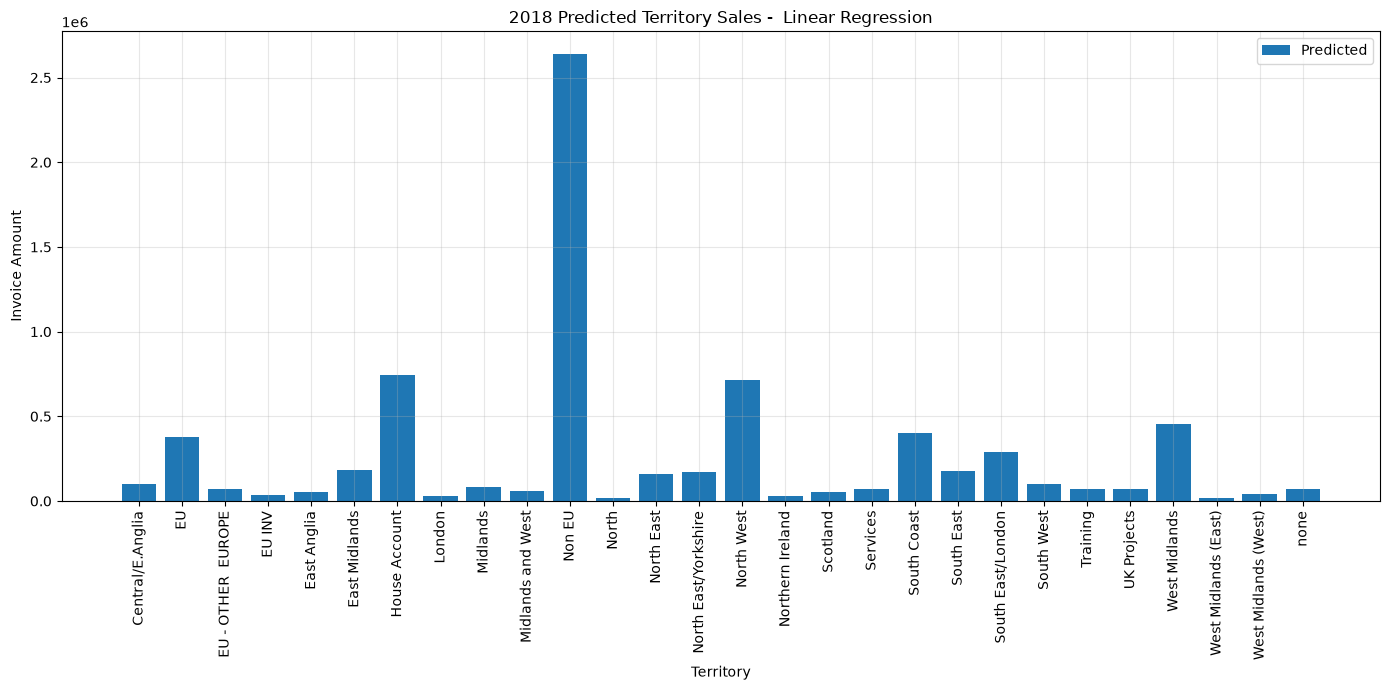

<Figure size 640x480 with 0 Axes>

In [117]:
#now plot the results for 2018 prediction 
plt.figure(figsize=(14, 7))

plt.bar(
    df2018Territory["TerritoryCodes"],      
    df2018Territory["Predicted_InvoiceAmt"],
    label="Predicted"
)

plt.title("2018 Predicted Territory Sales -  Linear Regression")
plt.xlabel("Territory")
plt.ylabel("Invoice Amount")

plt.xticks(rotation=90)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#save plot to file in reports folder
plt.savefig(
    CNST_STR_LINEAR_PLOT_HYPOTHESIS10_PREDICTIONS_PATH,
    dpi=300,
    bbox_inches="tight"
)

## Predict 2018 Figures - Random Forest Model

In [108]:
# ============================================================
# PREPARE COMPLETE DATASET
# ============================================================

dfSalesDataML_Work = (
    dfSalesDataML_GroupedByTerritory.copy()
)


# ============================================================
# CREATE MONTH
# ============================================================

dfSalesDataML_Work["Month"] = (
    dfSalesDataML_Work["YearMonth"] % 100
).astype(int)


#cyclic features
dfSalesDataML_Work["MonthSin"] = np.sin(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)

dfSalesDataML_Work["MonthCos"] = np.cos(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)

# ============================================================
# TRAINING DATA
#
# Use ALL available historical data:
# 2011-2017
# ============================================================

dfTrain = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] <= 2017
].copy()


print("Training Rows:", len(dfTrain))

print(
    "Training Years:",
    sorted(dfTrain["Year"].unique())
)

print()


# ============================================================
# FEATURES
# ============================================================

lstFeatures = [
    "TerritoryCodes",
    "Year",
    "MonthSin",
    "MonthCos"
]

strTarget = "InvoiceAmt"


dfXtrain = dfTrain[lstFeatures]
dfyTrain = dfTrain[strTarget]


# ============================================================
# PREPROCESSING
# ============================================================

lstNumericFeatures = [
    "Year",
    "MonthSin",
    "MonthCos"
]

lstCategoricalFeatures = [
    "TerritoryCodes"
]


objNumericTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)


objCategoricalTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)


objPreProcessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            objNumericTransformer,
            lstNumericFeatures
        ),
        (
            "categorical",
            objCategoricalTransformer,
            lstCategoricalFeatures
        )
    ]
)


# ============================================================
# MODEL
# ============================================================

#create random forest model
objModel = RandomForestRegressor(
    n_estimators=20,     #50
    max_depth=20,      #None
    min_samples_split=2, #2
    min_samples_leaf=1,  #1
    random_state=42,     
    n_jobs=-1
)


objPipeline = Pipeline(
    steps=[
        ("preprocessor", objPreProcessor),
        ("model", objModel)
    ]
)


# ============================================================
# TRAIN MODEL
# ============================================================

print("Training Random Forest using 2011-2017...")

objPipeline.fit(
    dfXtrain,
    dfyTrain
)

print("Training complete.")
print()


# ============================================================
# CREATE 2018 PREDICTION DATA
# ============================================================

# Get all territories that existed in 2017

lstTerritories = sorted(
    dfSalesDataML_Work[
        dfSalesDataML_Work["Year"] == 2017
    ]["TerritoryCodes"]
    .dropna()
    .unique()
)


# Create 12 months for every territory

df2018Predict = pd.DataFrame(
    [
        {
            "TerritoryCodes": territory,
            "Year": 2018,
            "Month": month,
            "YearMonth": 201800 + month
        }
        for territory in lstTerritories
        for month in range(1, 13)
    ]
)

#add cyclic features
df2018Predict["MonthSin"] = np.sin(
    2 * np.pi * df2018Predict["Month"] / 12
)

df2018Predict["MonthCos"] = np.cos(
    2 * np.pi * df2018Predict["Month"] / 12
)




# ============================================================
# PREDICT 2018
# ============================================================

dfX2018 = df2018Predict[
    lstFeatures
]


obj2018Predictions = (
    objPipeline.predict(
        dfX2018
    )
)


# Add predictions

df2018Predict[
    "Predicted_InvoiceAmt"
] = obj2018Predictions


# ============================================================
# DISPLAY PREDICTIONS
# ============================================================

print("2018 Forecast")
print("=" * 30)

print(
    df2018Predict.to_string(
        index=False
    )
)

print()


# ============================================================
# TOTAL 2018 FORECAST
# ============================================================

flt2018Total = (
    df2018Predict[
        "Predicted_InvoiceAmt"
    ].sum()
)

df2018Monthly = (
    df2018Predict
    .groupby("YearMonth")[
        "Predicted_InvoiceAmt"
    ]
    .sum()
    .reset_index()
)

print(df2018Monthly)

df2018Territory = (
    df2018Predict
    .groupby("TerritoryCodes")[
        "Predicted_InvoiceAmt"
    ]
    .sum()
    .reset_index()
)

print(df2018Territory)



print(
    f"Predicted 2018 Territory Sales: "
    f"£{flt2018Total:,.2f}"
)


#evaluate performance of the model
fltMAE = mean_absolute_error(dfyTest, objyPred)

fltRMSE = np.sqrt(
    mean_squared_error(dfyTest, objyPred)
)

fltR2 = r2_score(dfyTest, objyPred)

#show results
print("Random Forest Results")
print("=" * len("Random Forest Results"))
print(f"Mean Absolute Error (MAE):  {fltMAE:,.2f}")
print(f"Root Mean Squared Error (RMSE): {fltRMSE:,.2f}")
print(f"R-Squared (R²):   {fltR2:.4f}")
print()


#show OLS model summary for InvoiceAmt
ols_model = smf.ols(
    "InvoiceAmt ~ TerritoryCodes + Year + MonthSin + MonthCos",
    data=dfSalesDataML_Work
).fit()
print(ols_model.summary())
print()

#save piepline to main folder
joblib.dump(
    objPipeline,
    CNST_STR_FOREST_PIPELINE_HYPOTHESIS10_PREDICTIONS_PATH
)

print("Pipeline Saved To:")
print(CNST_STR_FOREST_PIPELINE_HYPOTHESIS10_PREDICTIONS_PATH)

Training Rows: 1669
Training Years: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017)]

Training Random Forest using 2011-2017...
Training complete.

2018 Forecast
      TerritoryCodes  Year  Month  YearMonth      MonthSin      MonthCos  Predicted_InvoiceAmt
    Central/E.Anglia  2018      1     201801  5.000000e-01  8.660254e-01           8184.408228
    Central/E.Anglia  2018      2     201802  8.660254e-01  5.000000e-01           8848.773390
    Central/E.Anglia  2018      3     201803  1.000000e+00  6.123234e-17           8857.146081
    Central/E.Anglia  2018      4     201804  8.660254e-01 -5.000000e-01           8825.556294
    Central/E.Anglia  2018      5     201805  5.000000e-01 -8.660254e-01           8107.575402
    Central/E.Anglia  2018      6     201806  1.224647e-16 -1.000000e+00           8379.030402
    Central/E.Anglia  2018      7     201807 -5.000000e-01 -8.660254e-01           8122.773322
    Central/E.

## Predict 2018 Figures - Random Forest Model - Plot

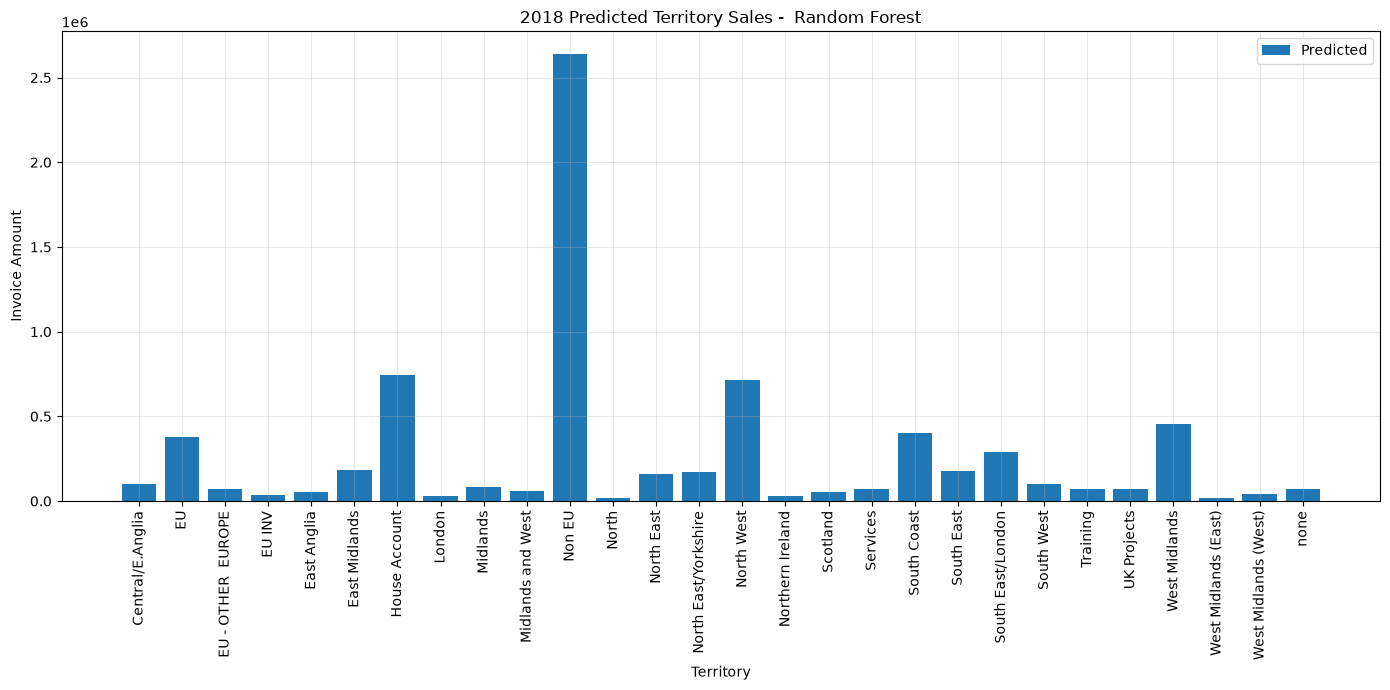

<Figure size 640x480 with 0 Axes>

In [119]:
#now plot the results for 2018 prediction 
plt.figure(figsize=(14, 7))

plt.bar(
    df2018Territory["TerritoryCodes"],      
    df2018Territory["Predicted_InvoiceAmt"],
    label="Predicted"
)

plt.title("2018 Predicted Territory Sales -  Random Forest")
plt.xlabel("Territory")
plt.ylabel("Invoice Amount")

plt.xticks(rotation=90)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#save plot to file in reports folder
plt.savefig(
    CNST_STR_FOREST_PLOT_HYPOTHESIS10_PREDICTIONS_PATH,
    dpi=300,
    bbox_inches="tight"
)

## Predict 2018 Figures - Random Forest Model - Plot

dd

## Conclusions

d